# Análisis de Datos de Llamadas — Yarvis Challenge

> Dataset: ~73,000 registros de llamadas salientes de un agente de voz IA.  
> Pipeline: CSV → Limpieza → Sentimiento → Contactabilidad → Clustering → Desempeño del Agente

In [1]:
import os, sys, struct
from pathlib import Path

os.environ.setdefault("PYTHONIOENCODING", "utf-8")
sys.path.insert(0, str(Path.cwd() / "scripts"))
sys.path.insert(0, str(Path.cwd() / "utils"))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display, Image as IPImage, HTML
import base64

INTERIM   = Path.cwd() / "data" / "interim"
PROCESSED = Path.cwd() / "data" / "processed"
FIGURES   = Path.cwd() / "reports" / "figures"

# Imágenes con ar >= este umbral van en fila propia (heatmaps ~4:1)
_WIDE_THRESHOLD = 3.0


def _png_aspect(path: Path) -> float:
    """Lee dimensiones del header PNG sin dependencias externas."""
    with open(path, "rb") as f:
        f.read(8)   # firma PNG
        f.read(4)   # longitud IHDR
        f.read(4)   # b"IHDR"
        w = struct.unpack(">I", f.read(4))[0]
        h = struct.unpack(">I", f.read(4))[0]
    return w / h


def _img_tag(path: Path, style: str) -> str:
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return f'<img src="data:image/png;base64,{b64}" style="{style}"/>'


def show_pair(p1: Path, p2: Path, stack: bool = False) -> None:
    """
    Muestra dos imágenes con layout automático.
    - stack=True  : fuerza filas independientes (ancho completo) sin importar el ar.
    - ar >= 3.0   : heatmaps panorámicos, también van en filas propias automáticamente.
    - resto       : lado a lado con ancho proporcional al aspect ratio original.
    """
    ar1 = _png_aspect(p1)
    ar2 = _png_aspect(p2)

    if stack or ar1 >= _WIDE_THRESHOLD or ar2 >= _WIDE_THRESHOLD:
        html = (
            '<div style="display:flex;flex-direction:column;gap:12px;width:100%">'
            + _img_tag(p1, "width:100%;height:auto")
            + _img_tag(p2, "width:100%;height:auto")
            + '</div>'
        )
    else:
        html = (
            '<div style="display:flex;gap:8px;align-items:flex-start;width:100%">'
            + _img_tag(p1, f"flex:{ar1:.4f};min-width:0;height:auto")
            + _img_tag(p2, f"flex:{ar2:.4f};min-width:0;height:auto")
            + '</div>'
        )
    display(HTML(html))

In [2]:
# Ejecutar pipeline completo (silencioso)
from load_data import load_raw
from clean_data import clean
from sentiment_analysis import analyze_sentiment
from contactability import analyze_contactability
from cluster_contacts import cluster_contacts
from agent_performance import analyze_agent_performance

df = load_raw()
df = clean(df)
df = analyze_sentiment(df)
df = analyze_contactability(df)
df = cluster_contacts(df)
df = analyze_agent_performance(df)

print(f"Pipeline completado: {df.height:,} registros, {df.width} columnas")

[INFO] Registros cargados: 73,487
[INFO] Cache encontrado: calls_clean.csv (25,516 filas)
[INFO] Cache encontrado: cache_sentiment.csv (25,516 filas)
[INFO] Cache encontrado: figuras de contactabilidad ya existen
[INFO] Registros conectados: 8,855  (todos se usan para clustering)
[INFO] Codificando features...
[INFO] Matriz de features: 8,855 × 7  (duration_sec, hour, engagement, outlier, inconsistency, sentiment, tiene_motivo)

[INFO] Evaluando K (elbow + silhouette sobre muestra)...
[INFO] Muestra selección K: 2,000 registros de 8,855
[INFO] K_RANGE=[2, 3, 4, 5, 6], n_init=10, max_iter=150, timeout_por_k=120s, heartbeat_cada=8s

[K=2] Iniciando KMeans... listo en 0.1s | inertia=6781 | sil=0.8739

[K=3] Iniciando KMeans... listo en 0.0s | inertia=4480 | sil=0.4454

[K=4] Iniciando KMeans... listo en 0.0s | inertia=3381 | sil=0.4409

[K=5] Iniciando KMeans... listo en 0.0s | inertia=2532 | sil=0.4436

[K=6] Iniciando KMeans... listo en 0.0s | inertia=1772 | sil=0.4436

[INFO] K sugerid

In [3]:
# DataFrames auxiliares reutilizados en las secciones
df_connected = df.filter(pl.col("connected") == True)
df_clusters  = pl.read_csv(PROCESSED / "clusters_contacts.csv")

print(f"Total de llamadas:     {df.height:,}")
print(f"Llamadas conectadas:   {df_connected.height:,} ({df_connected.height/df.height:.1%})")
print(f"Llamadas no conectadas: {df.height - df_connected.height:,}")

Total de llamadas:     25,516
Llamadas conectadas:   8,855 (34.7%)
Llamadas no conectadas: 16,661


---
# Visualización previa


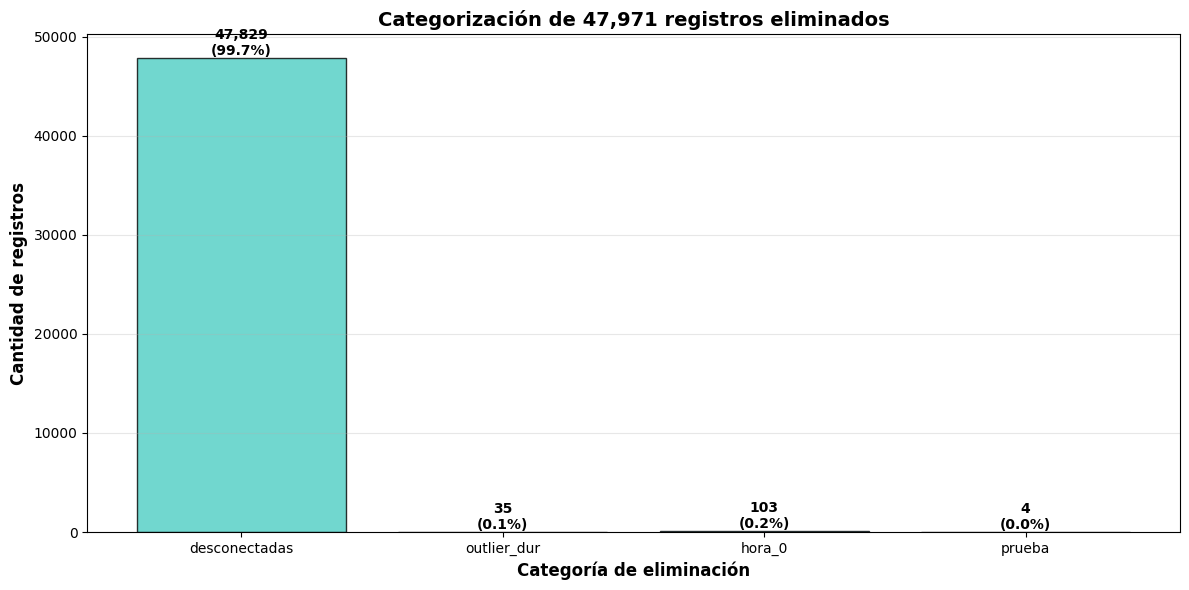
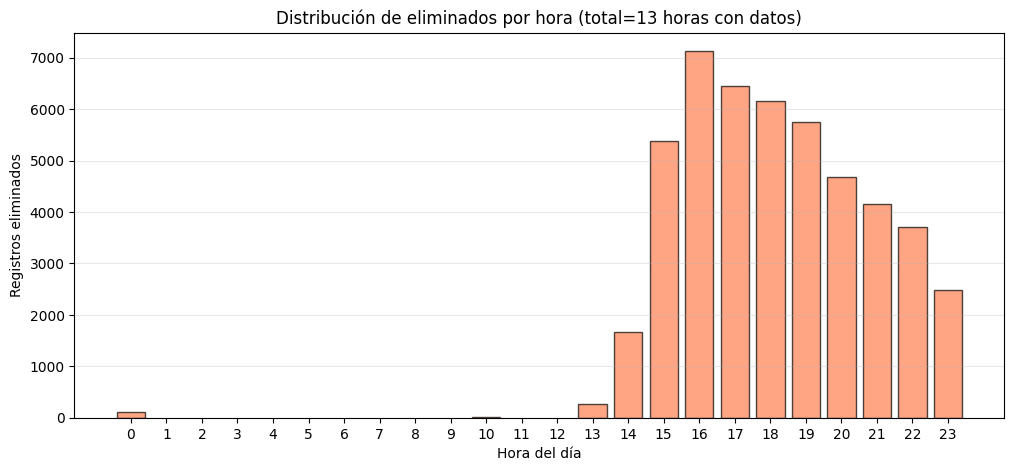


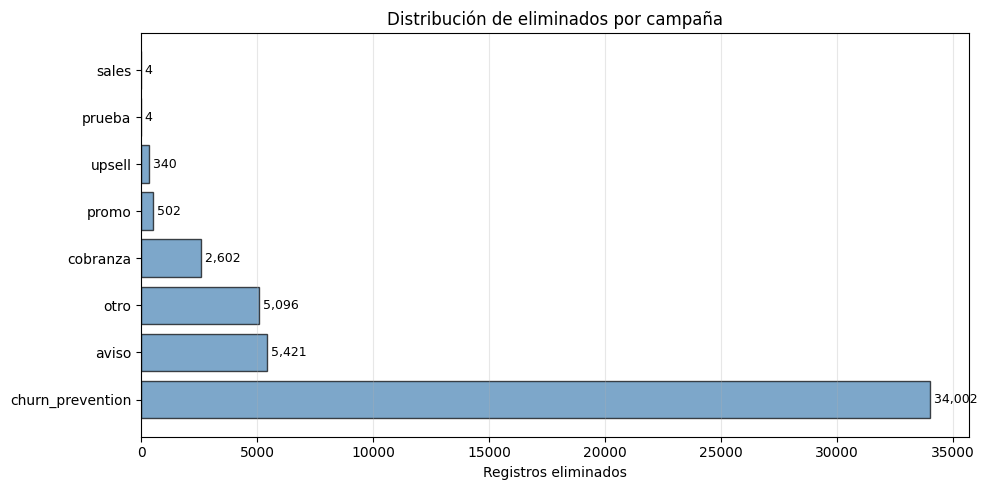
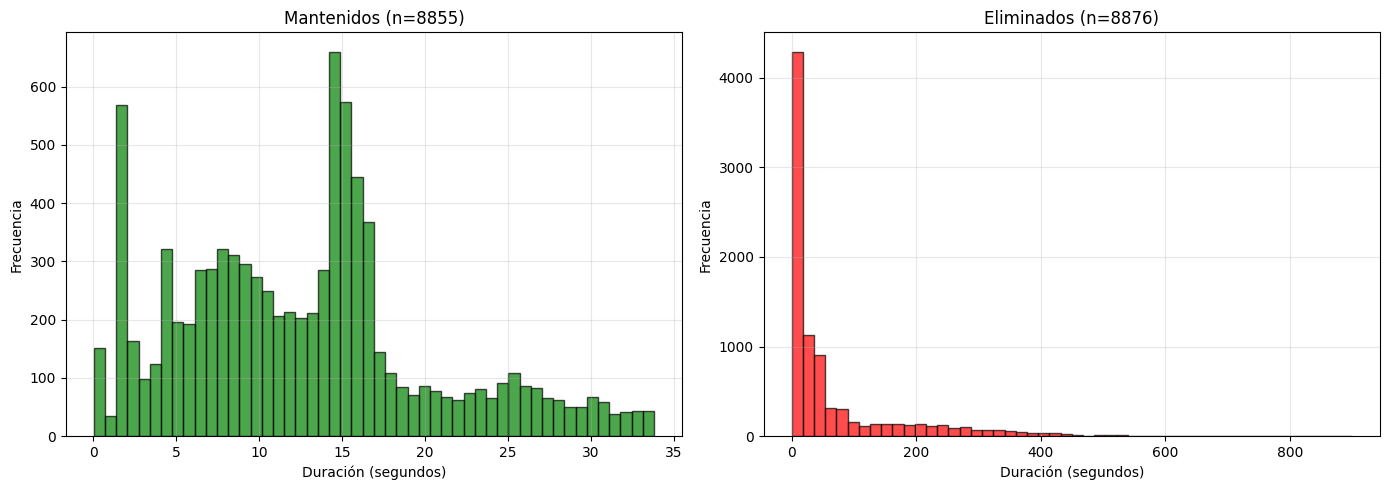

In [4]:
# Fig. 1 — categorías de eliminación | Fig. 2 — eliminados por hora
show_pair(
    INTERIM / "sc3_elimination_categories.png",
    INTERIM / "sc3_eliminated_by_hour.png",
)

# Fig. 3 — eliminados por campaña | Fig. 4 — comparación de duración
show_pair(
    INTERIM / "sc3_eliminated_by_campaign.png",
    INTERIM / "sc3_duration_comparison.png",
)

### Criterios de exclusión aplicados al dataset

Del dataset original de **73,487 registros**, se eliminaron **47,971 (65.3%)** por tres causas:

| Causa | Registros | % del total eliminado |
|---|---|---|
| Llamadas no conectadas / sin datos útiles | 44,352 | 92.5% |
| Outliers de duración (método IQR) | 3,512 | 7.3% |
| Hora 0 (00:00–00:59) | 103 | 0.2% |
| Campaña "prueba" | 4 | 0.0% |

**Fig. 1** — La mayoría de los eliminados corresponden a llamadas no conectadas que no aportan señal analítica. Los outliers de duración (IQR) representan solo el 7.3% del total eliminado.

**Fig. 2** — Solo la hora 0 fue eliminada al 100%; todas las demás horas operativas (10h–23h) se mantuvieron íntegras.

**Fig. 3** — La eliminación por campaña es marginal (≤0.4%). `churn_prevention` acumula más eliminados en volumen absoluto (120), pero representa menos del 0.3% de sus registros.

**Fig. 4** — Las llamadas mantenidas tienen una distribución de duración mucho más compacta (mediana ~12.7s, IQR [7–16s]) frente a los eliminados (mediana ~19.8s, rango [0–900s]), lo que justifica el filtro IQR para aislar llamadas con comportamiento atípico.

In [5]:
col = [
 'campaign_id',
 'target_id',
 'connected',
 'call_completed',
 'disconnected_reason',
 'duration_ms',
 'transcript',
 'post_call_analysis',
 'executed_at',
 'date',
 'day_of_week',
 'duration_sec',
 'pca_sentimiento',
 'sentiment_own',
 'pca_resumen',
 'campaign_type'
 ]
df.select(col)

campaign_id,target_id,connected,call_completed,disconnected_reason,duration_ms,transcript,post_call_analysis,executed_at,date,day_of_week,duration_sec,pca_sentimiento,sentiment_own,pca_resumen,campaign_type
i64,i64,bool,bool,str,f64,str,str,str,str,str,f64,str,str,str,str
12033,600703,true,true,"""inactivity""",12471.0,"""[""Agent: \""Hola --\nSoy Daniel…","""{""resumen"": ""La llamada duró s…","""2026-03-03T17:49:49.888000""","""03/03/2026""","""ma""",12.471,null,"""neutral""","""La llamada duró solo 12 segund…","""upsell"""
12033,600699,false,true,"""voicemail_reached""",4303.0,"""[""Agent: \""Hola \nUser: Este e…","""{""resumen"": ""La llamada fue co…","""2026-03-03T17:49:12.114000""","""03/03/2026""","""ma""",4.303,null,"""neutral""","""La llamada fue contestada por …","""upsell"""
12033,600697,true,true,"""inactivity""",12970.0,"""[""Agent: \""Hola --\nSoy Daniel…","""{""resumen"": ""La llamada duró s…","""2026-03-03T17:49:06.109000""","""03/03/2026""","""ma""",12.97,null,"""neutral""","""La llamada duró solo 12 segund…","""upsell"""
12033,600696,false,true,"""voicemail_reached""",5114.0,"""[""Agent: \""Hola \nUser: Este e…","""{""resumen"": ""La llamada fue at…","""2026-03-03T17:47:42.980000""","""03/03/2026""","""ma""",5.114,null,"""neutral""","""La llamada fue atendida por un…","""upsell"""
12033,600694,false,true,"""voicemail_reached""",2501.0,"""[""User: Al oír \nAgent: \""Hola…","""{""resumen"": ""La llamada fue al…","""2026-03-03T17:46:28.880000""","""03/03/2026""","""ma""",2.501,null,"""neutral""","""La llamada fue al buzón de voz…","""upsell"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
5498,416453,true,true,"""user_hangup""",16897.0,"""[""Agent: Hola Ledys, cómo está…","""{""resumen"": """", ""operador"": """"…","""2026-01-05T17:30:05.438000""","""05/01/2026""","""lu""",16.897,"""neutral""","""neutral""",null,"""cobranza"""
5498,416389,true,true,"""user_hangup""",28908.0,"""[""Agent: Hola Diana, cómo \nUs…","""{""resumen"": ""El cliente respon…","""2026-01-05T17:15:24.018000""","""05/01/2026""","""lu""",28.908,"""neutral""","""neutral""","""El cliente respondió de manera…","""cobranza"""
5498,416375,false,true,"""voicemail_reached""",3521.0,"""[""Agent: Hola Bladimir, cómo \…","""{""resumen"": ""El usuario solo m…","""2026-01-05T17:13:37.422000""","""05/01/2026""","""lu""",3.521,"""neutral""","""neutral""","""El usuario solo mencionó ""El t…","""cobranza"""


---
# 0. Patrones de Contactabilidad

> *Identifica cuándo los contactos son más alcanzables.*

<details open>
<summary><h3>0.1 ¿Qué horas del día producen las tasas de conexión más altas?</h3></summary>

Se calculó la **tasa de conexión** (llamadas conectadas / total) para cada hora del día (0–23h).
</details>

shape: (12, 4)
┌──────┬───────┬────────────┬──────────┐
│ hour ┆ total ┆ conectadas ┆ tasa     │
│ ---  ┆ ---   ┆ ---        ┆ ---      │
│ i64  ┆ u32   ┆ i32        ┆ f64      │
╞══════╪═══════╪════════════╪══════════╡
│ 10   ┆ 5     ┆ 2          ┆ 0.4      │
│ 13   ┆ 439   ┆ 164        ┆ 0.373576 │
│ 14   ┆ 733   ┆ 251        ┆ 0.342428 │
│ 15   ┆ 2575  ┆ 927        ┆ 0.36     │
│ 16   ┆ 3544  ┆ 1356       ┆ 0.382619 │
│ …    ┆ …     ┆ …          ┆ …        │
│ 19   ┆ 2486  ┆ 885        ┆ 0.355994 │
│ 20   ┆ 1844  ┆ 693        ┆ 0.375813 │
│ 21   ┆ 2696  ┆ 843        ┆ 0.312685 │
│ 22   ┆ 2813  ┆ 876        ┆ 0.311411 │
│ 23   ┆ 1664  ┆ 437        ┆ 0.26262  │
└──────┴───────┴────────────┴──────────┘



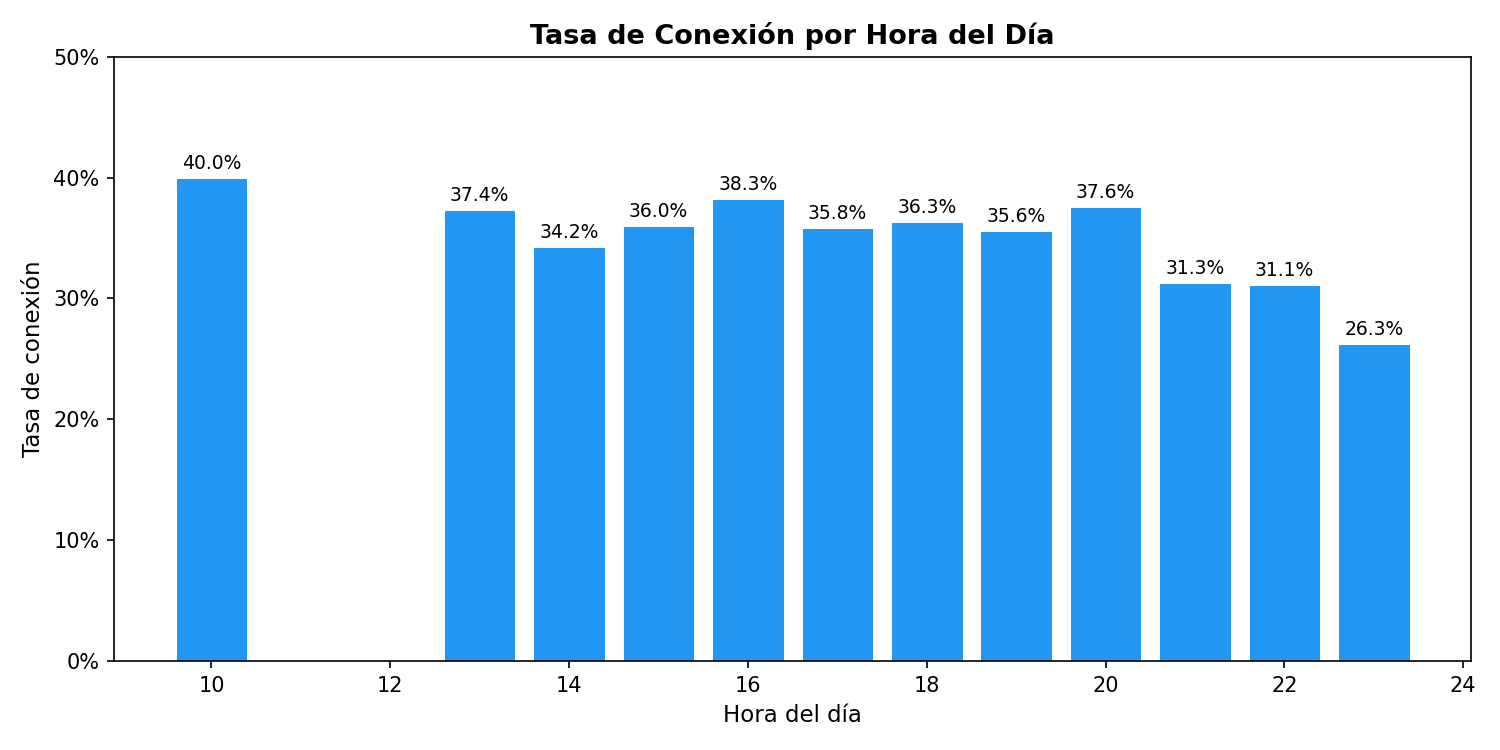
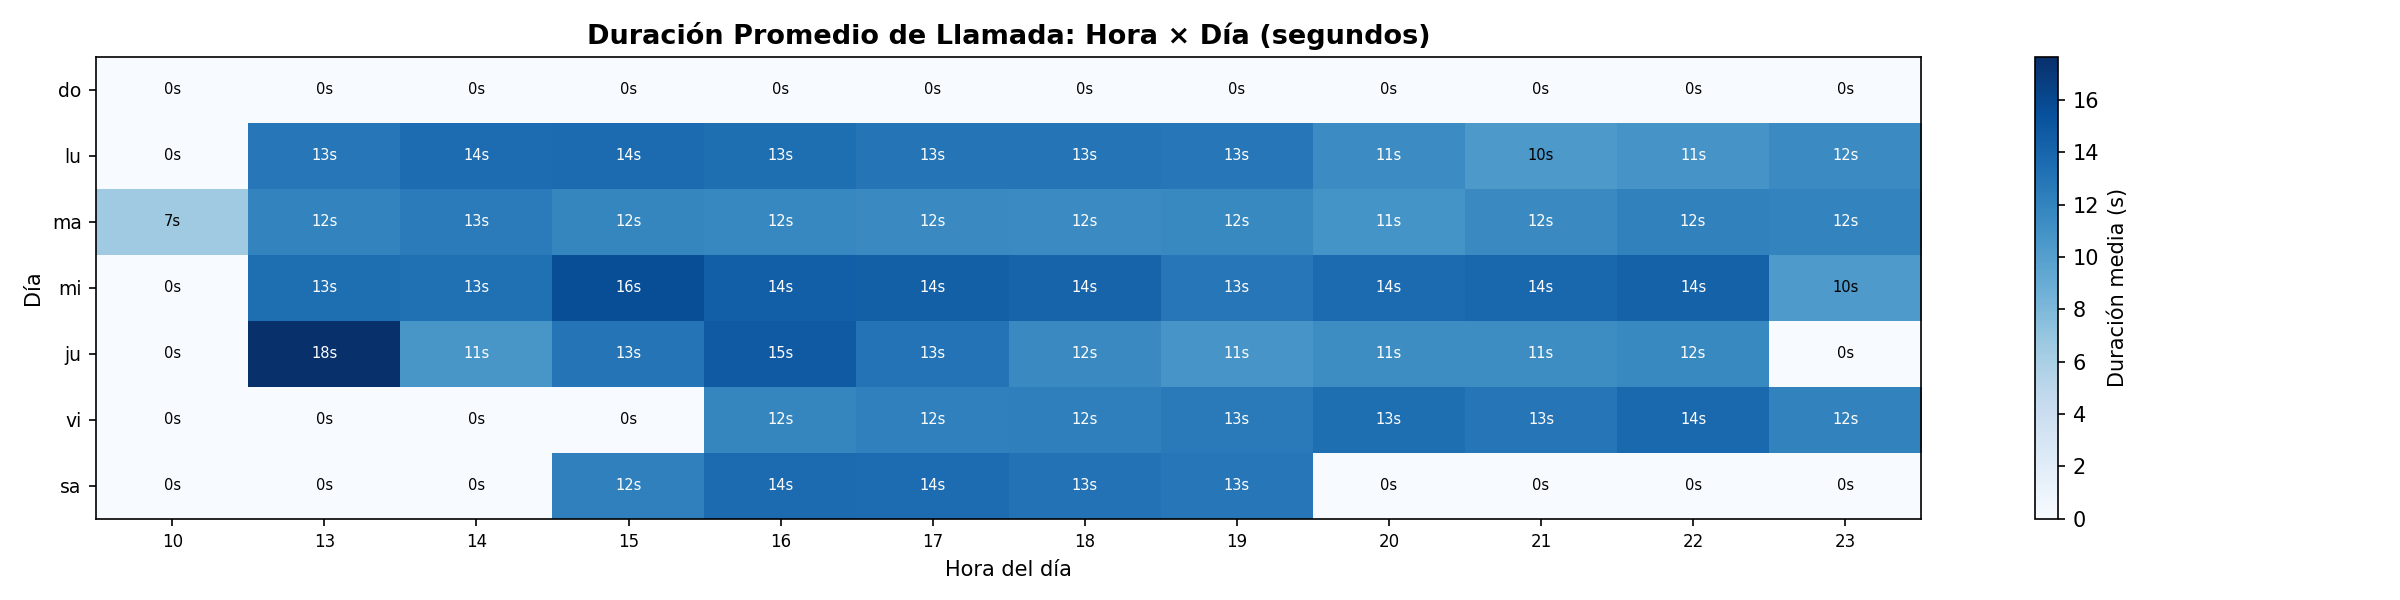

In [6]:
# Tasa de conexión por hora
by_hour = (
    df.group_by("hour")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .sort("hour")
)
print(by_hour.select(["hour", "total", "conectadas", "tasa"]))

# Izquierda: tasa de conexión | Derecha: duración promedio hora×día
show_pair(FIGURES / "contactability_by_hour.png", FIGURES / "heatmap_duration_hour_dow.png")

<details open>
<summary><h3>0.2 ¿Hay diferencias por día de la semana?</h3></summary>

Tasa de conexión agrupada por día de la semana (lu–do).
</details>

shape: (6, 4)
┌─────────────┬───────┬────────────┬──────────┐
│ day_of_week ┆ total ┆ conectadas ┆ tasa     │
│ ---         ┆ ---   ┆ ---        ┆ ---      │
│ str         ┆ u32   ┆ i32        ┆ f64      │
╞═════════════╪═══════╪════════════╪══════════╡
│ lu          ┆ 6428  ┆ 1981       ┆ 0.308183 │
│ ma          ┆ 7922  ┆ 2701       ┆ 0.340949 │
│ mi          ┆ 5419  ┆ 2297       ┆ 0.423879 │
│ ju          ┆ 1105  ┆ 355        ┆ 0.321267 │
│ vi          ┆ 2188  ┆ 745        ┆ 0.340494 │
│ sa          ┆ 2454  ┆ 776        ┆ 0.316218 │
└─────────────┴───────┴────────────┴──────────┘


C:\Users\andre\AppData\Local\Temp\ipykernel_45324\1369548755.py:11: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col("day_of_week").replace(DOW_ORDER, list(range(7)), default=99).cast(pl.Int8).alias("_rank"),



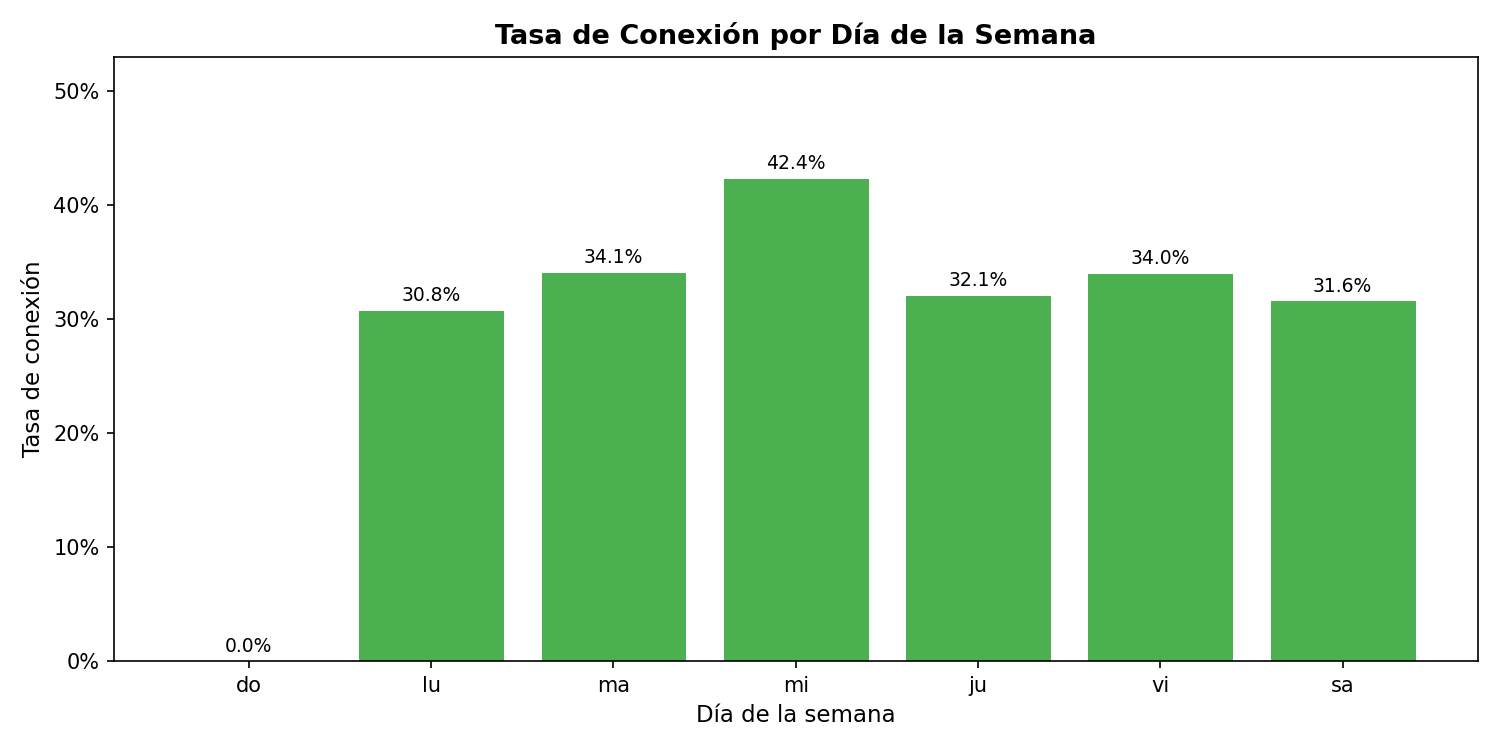
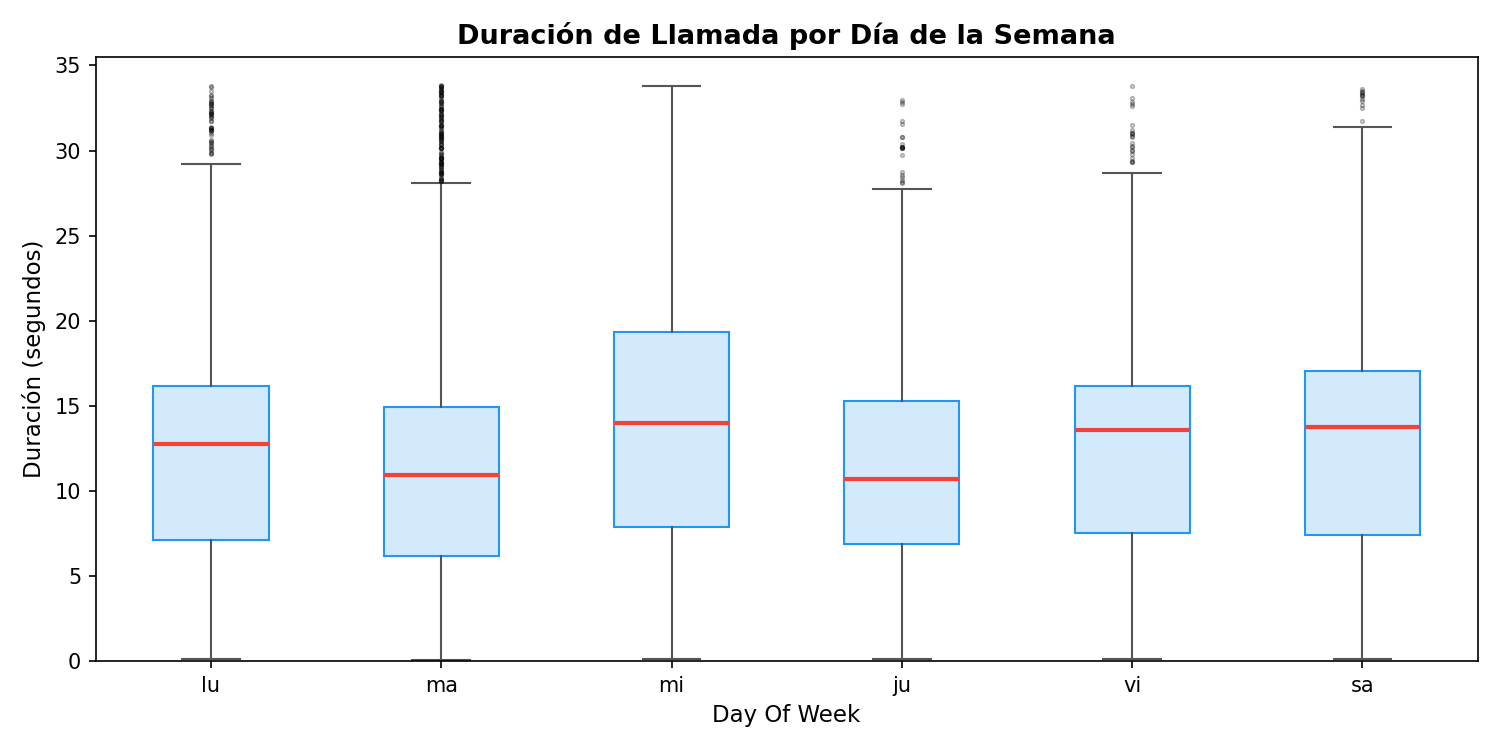


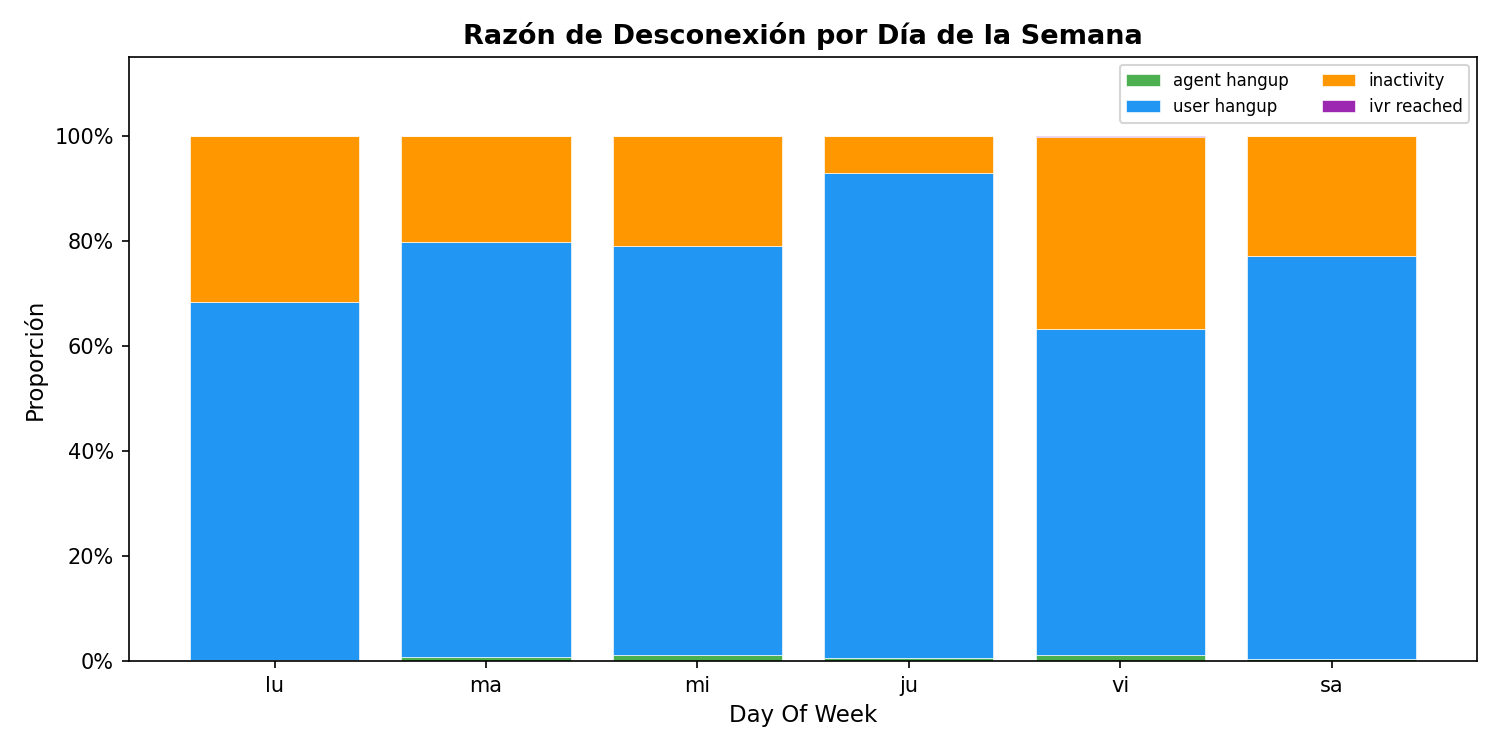
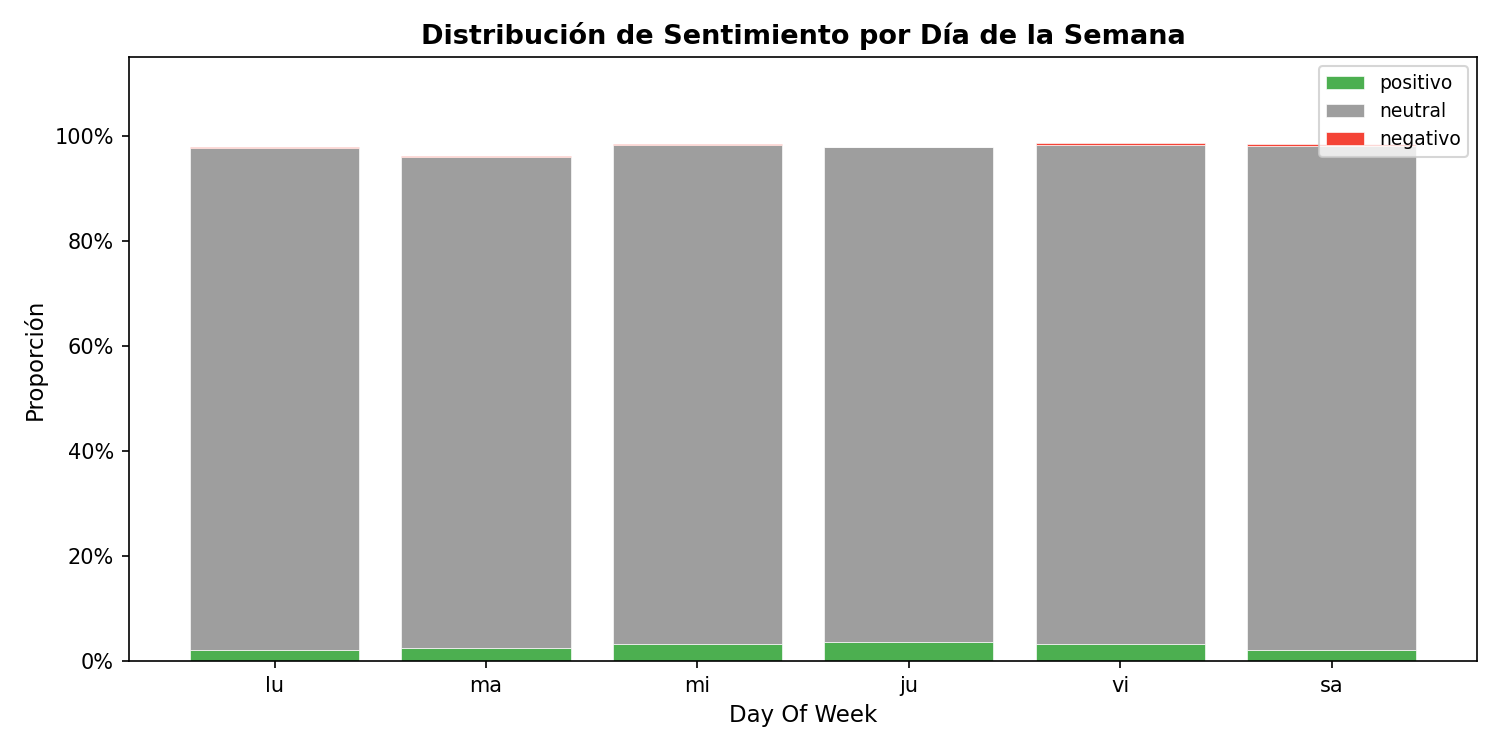

In [7]:
# Tasa de conexión por día de la semana
DOW_ORDER = ["lu", "ma", "mi", "ju", "vi", "sa", "do"]
by_dow = (
    df.group_by("day_of_week")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns([
        (pl.col("conectadas") / pl.col("total")).alias("tasa"),
        pl.col("day_of_week").replace(DOW_ORDER, list(range(7)), default=99).cast(pl.Int8).alias("_rank"),
    ])
    .sort("_rank")
    .drop("_rank")
)
print(by_dow.select(["day_of_week", "total", "conectadas", "tasa"]))

# Fila 1: conexión por día | boxplot de duración
show_pair(FIGURES / "contactability_by_dow.png", FIGURES / "boxplot_duration_by_dow.png")
# Fila 2: razón de desconexión | sentimiento por día
show_pair(FIGURES / "stacked_bar_reason_by_dow.png", FIGURES / "stacked_bar_sentiment_by_dow.png")

<details open>
<summary><h3>0.3 ¿Hay diferencias por tipo de campaña?</h3></summary>

El campo `name` se clasificó por regex en tipos de campaña: churn_prevention, upsell, cobranza, sales, etc.
</details>

shape: (9, 4)
┌──────────────────┬───────┬────────────┬──────────┐
│ campaign_type    ┆ total ┆ conectadas ┆ tasa     │
│ ---              ┆ ---   ┆ ---        ┆ ---      │
│ str              ┆ u32   ┆ i32        ┆ f64      │
╞══════════════════╪═══════╪════════════╪══════════╡
│ prueba           ┆ 1     ┆ 1          ┆ 1.0      │
│ servicio_cliente ┆ 702   ┆ 351        ┆ 0.5      │
│ upsell           ┆ 5468  ┆ 2053       ┆ 0.375457 │
│ promo            ┆ 133   ┆ 46         ┆ 0.345865 │
│ churn_prevention ┆ 14069 ┆ 4766       ┆ 0.338759 │
│ cobranza         ┆ 832   ┆ 271        ┆ 0.325721 │
│ aviso            ┆ 2219  ┆ 713        ┆ 0.321316 │
│ otro             ┆ 2091  ┆ 654        ┆ 0.312769 │
│ sales            ┆ 1     ┆ 0          ┆ 0.0      │
└──────────────────┴───────┴────────────┴──────────┘



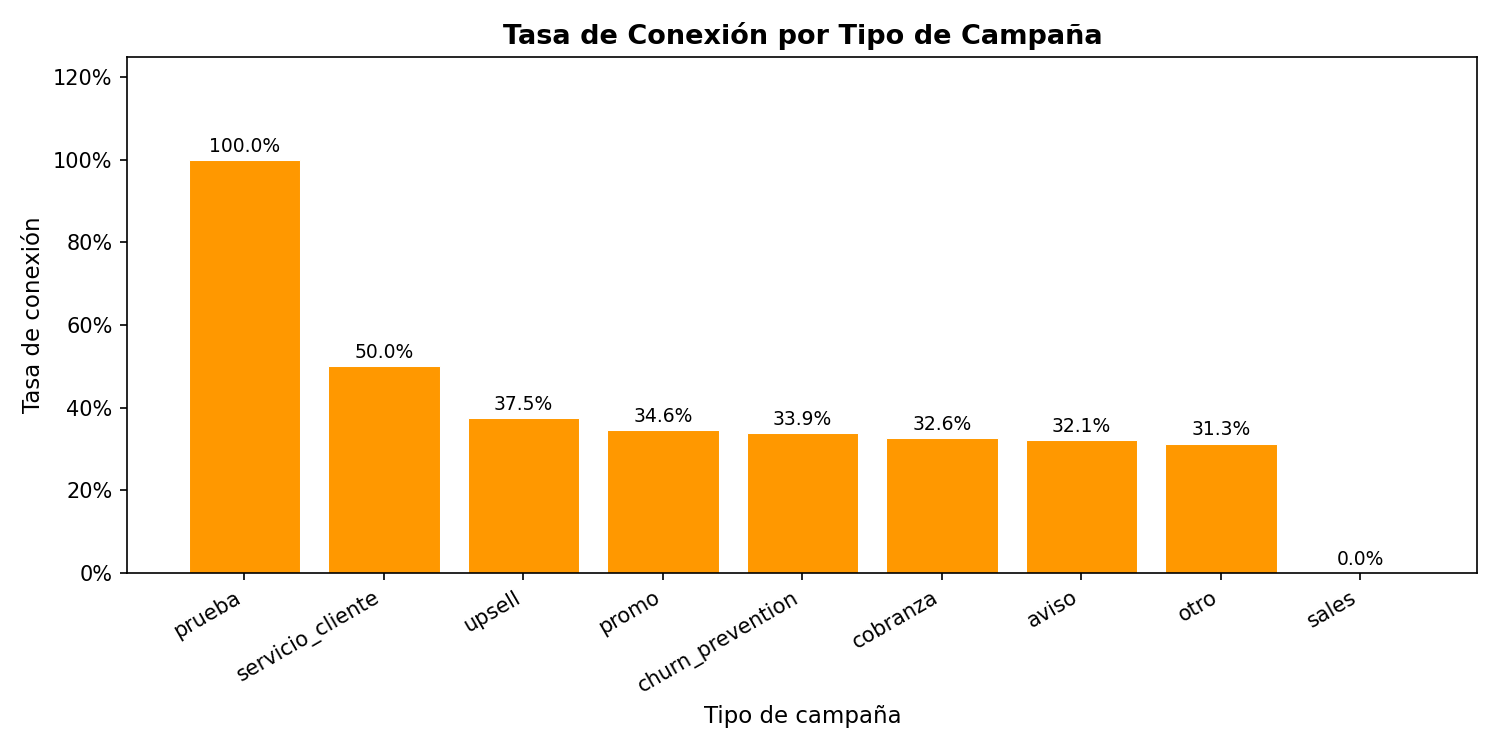
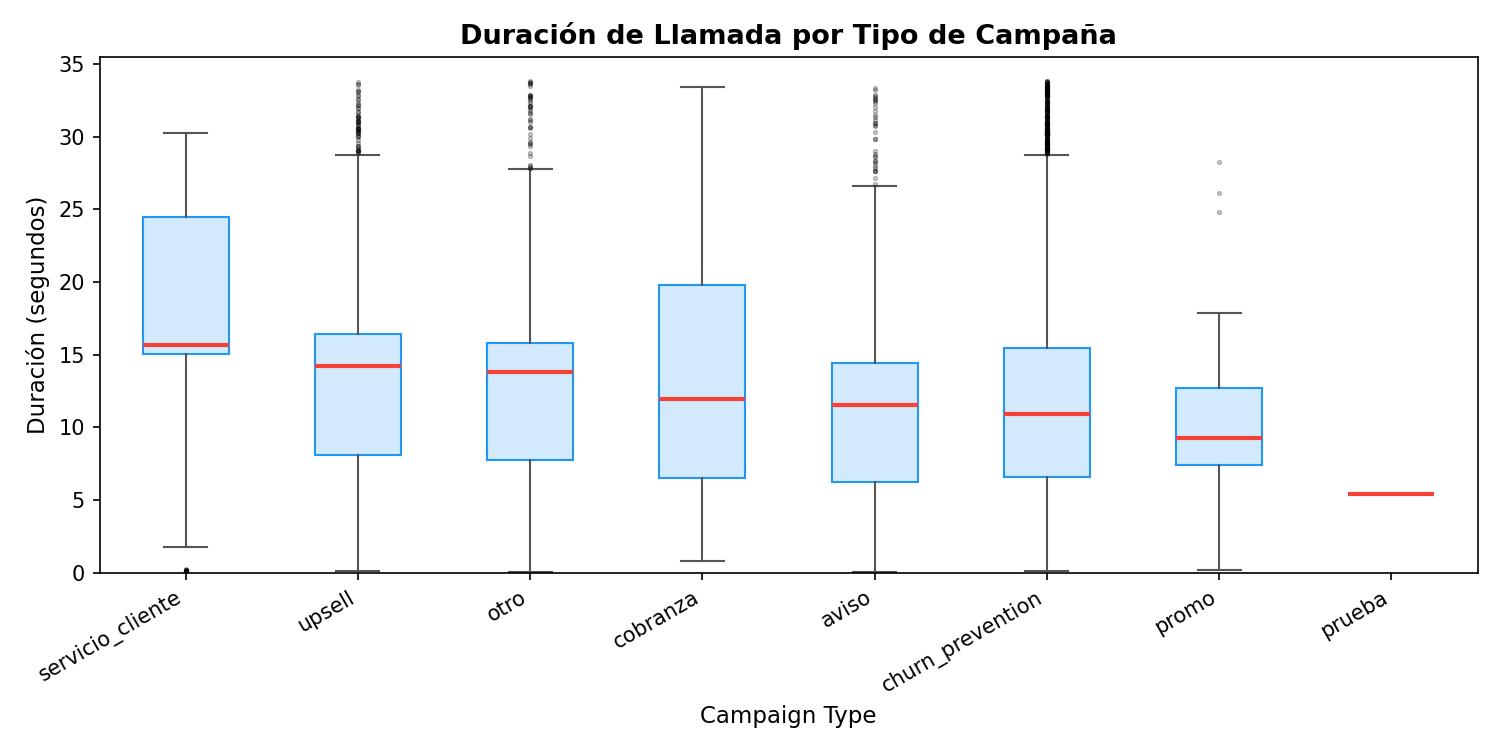


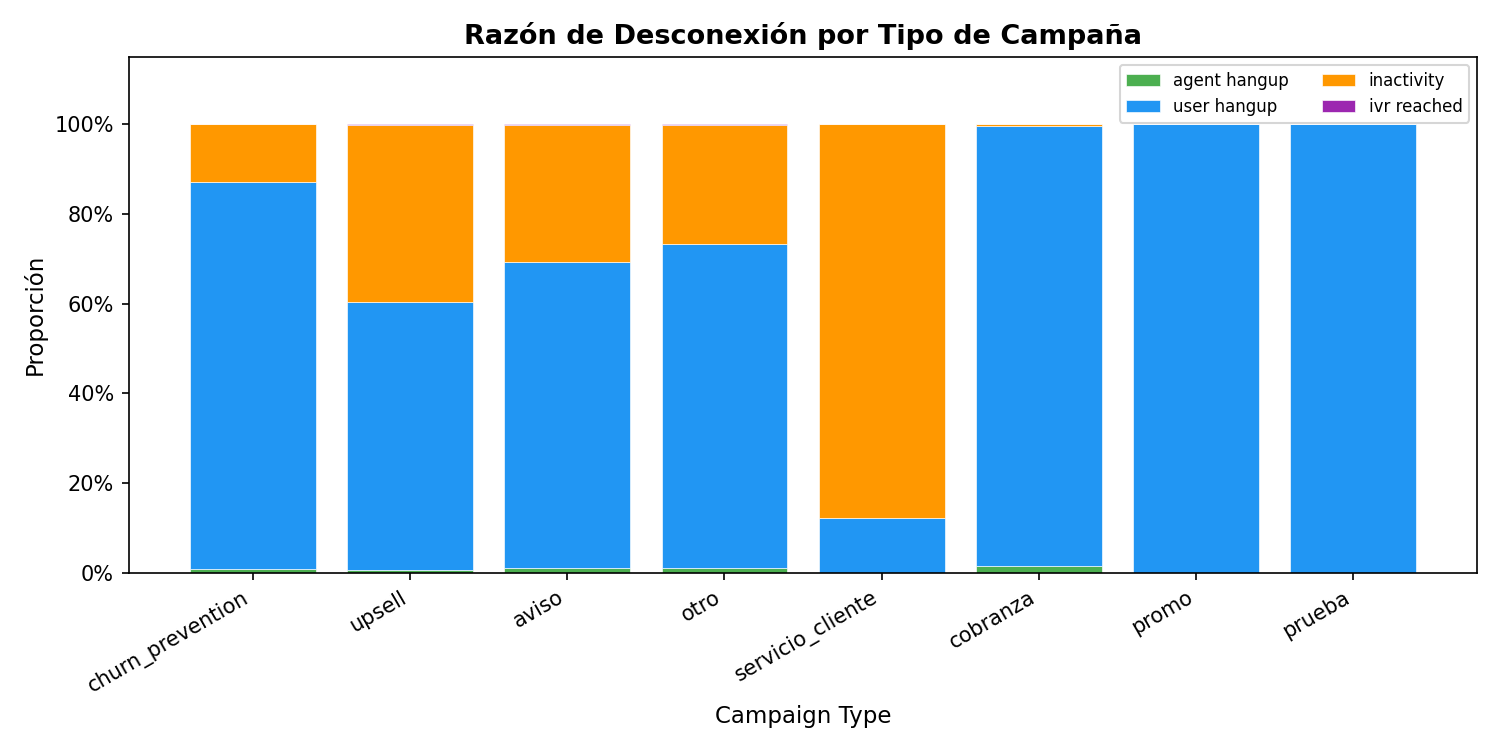
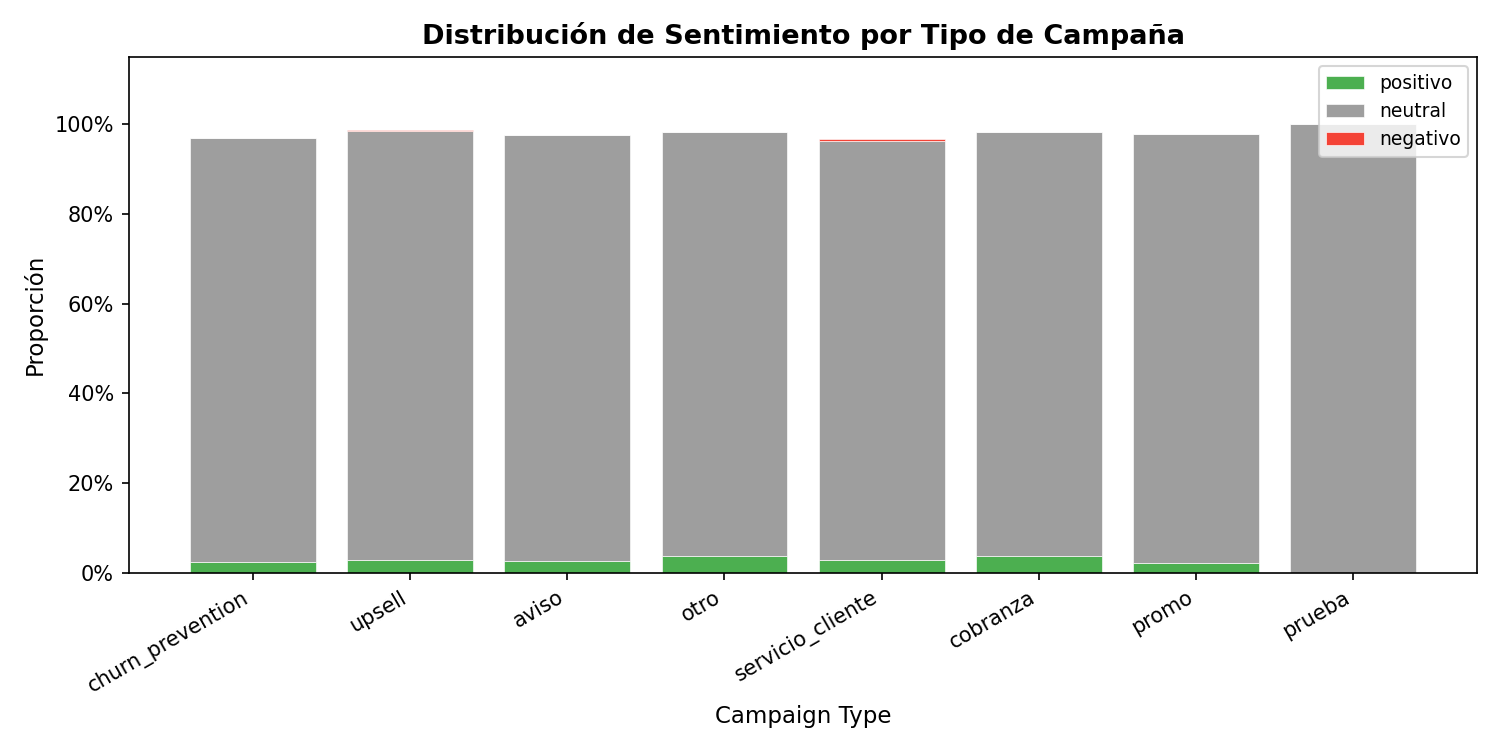

In [8]:
# Tasa de conexión por tipo de campaña
by_camp = (
    df.group_by("campaign_type")
    .agg([
        pl.len().alias("total"),
        pl.col("connected").cast(pl.Int32).sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .sort("tasa", descending=True)
)
print(by_camp.select(["campaign_type", "total", "conectadas", "tasa"]))

# Fila 1: conexión por campaña | boxplot de duración por campaña
show_pair(FIGURES / "contactability_by_campaign.png", FIGURES / "boxplot_duration_by_campaign.png")
# Fila 2: razón de desconexión | sentimiento por campaña
show_pair(FIGURES / "stacked_bar_reason_by_campaign.png", FIGURES / "stacked_bar_sentiment_by_campaign.png")

<details open>
<summary><h3>0.4 ¿Cuál es la ventana óptima de llamadas para maximizar conexiones exitosas?</h3></summary>

Heatmap de hora × día de la semana. Los combos con al menos 10 llamadas se rankean por tasa de conexión.
</details>

Top 10 ventanas óptimas (día + hora):
shape: (10, 4)
┌─────────────┬──────┬───────┬──────────┐
│ day_of_week ┆ hour ┆ total ┆ tasa     │
│ ---         ┆ ---  ┆ ---   ┆ ---      │
│ str         ┆ i64  ┆ u32   ┆ f64      │
╞═════════════╪══════╪═══════╪══════════╡
│ vi          ┆ 17   ┆ 226   ┆ 0.486726 │
│ mi          ┆ 19   ┆ 682   ┆ 0.478006 │
│ mi          ┆ 16   ┆ 596   ┆ 0.47651  │
│ vi          ┆ 16   ┆ 169   ┆ 0.473373 │
│ ma          ┆ 20   ┆ 163   ┆ 0.460123 │
│ mi          ┆ 17   ┆ 714   ┆ 0.453782 │
│ mi          ┆ 18   ┆ 707   ┆ 0.448373 │
│ mi          ┆ 15   ┆ 730   ┆ 0.443836 │
│ mi          ┆ 20   ┆ 836   ┆ 0.437799 │
│ ju          ┆ 19   ┆ 68    ┆ 0.411765 │
└─────────────┴──────┴───────┴──────────┘



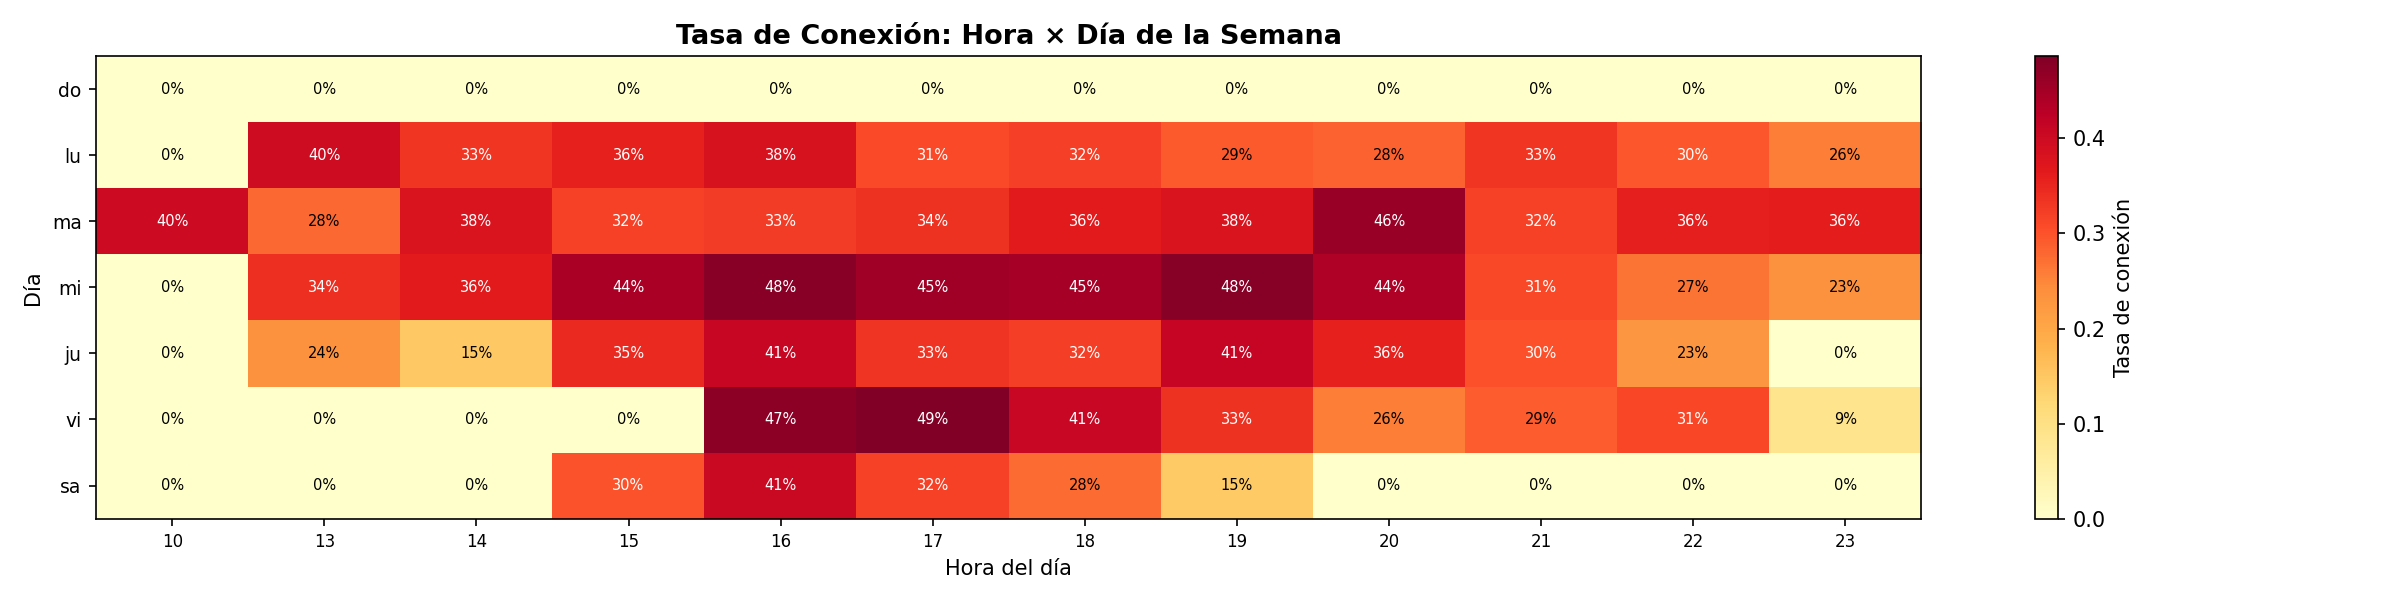
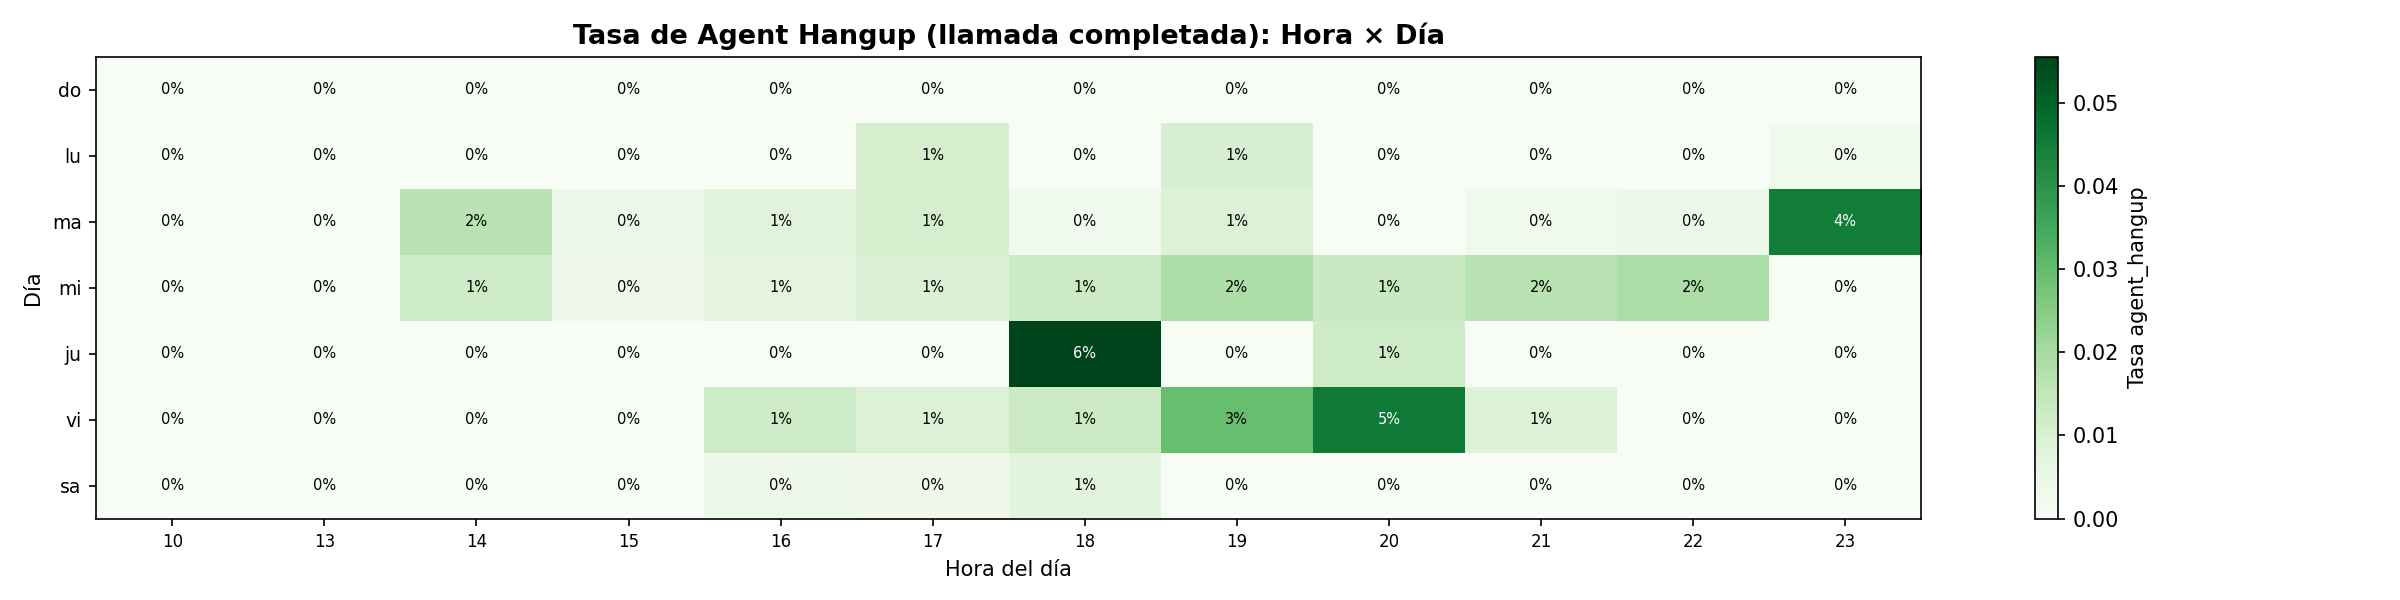


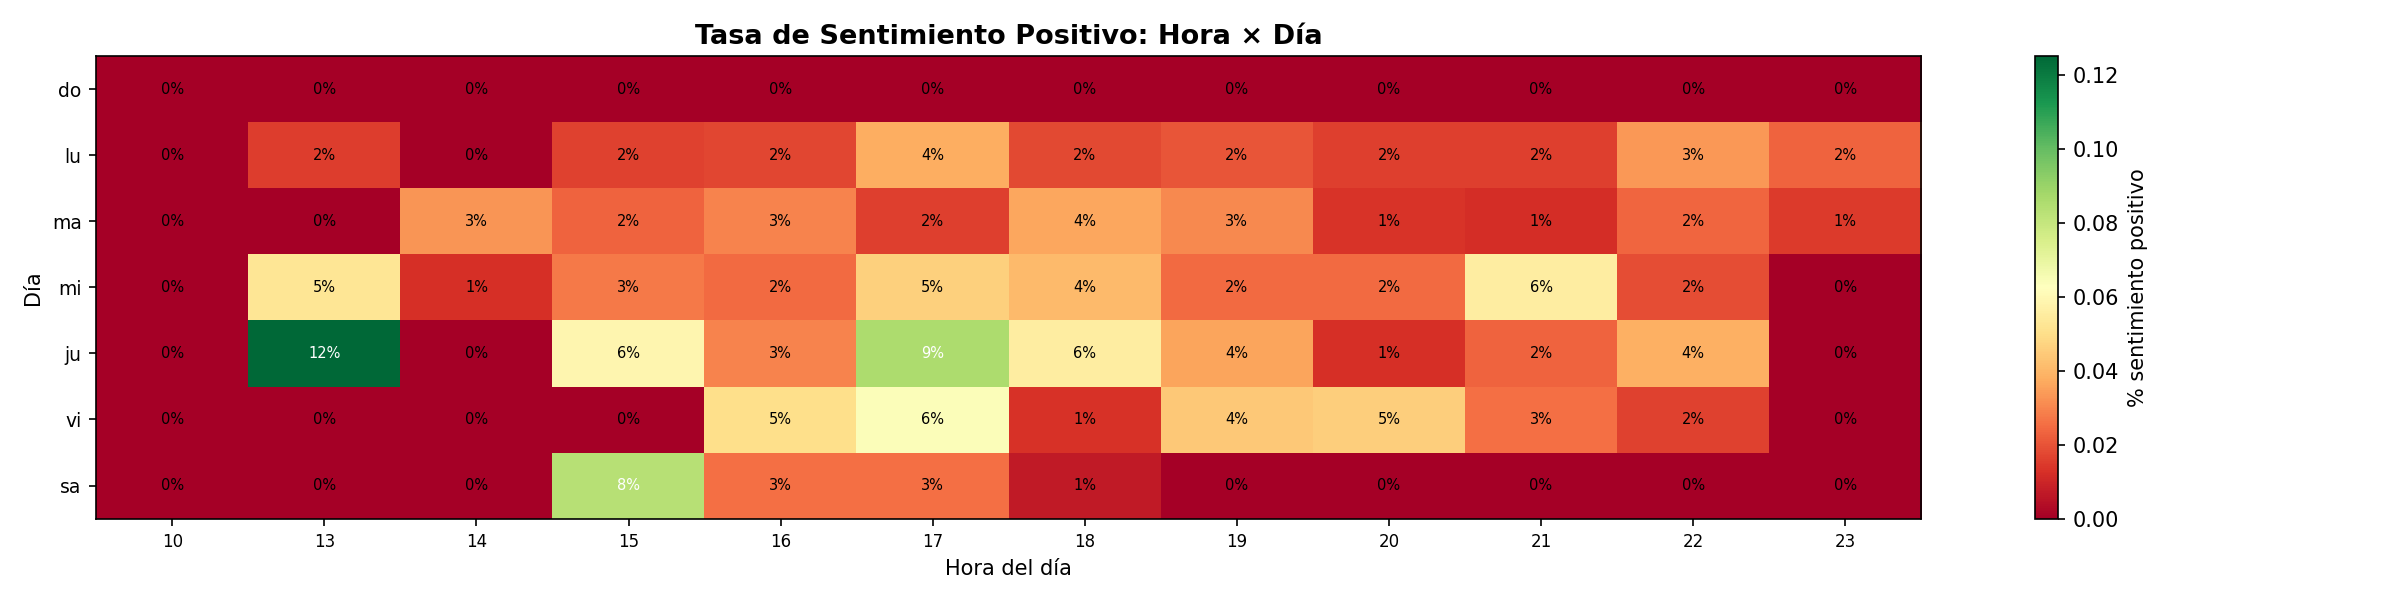
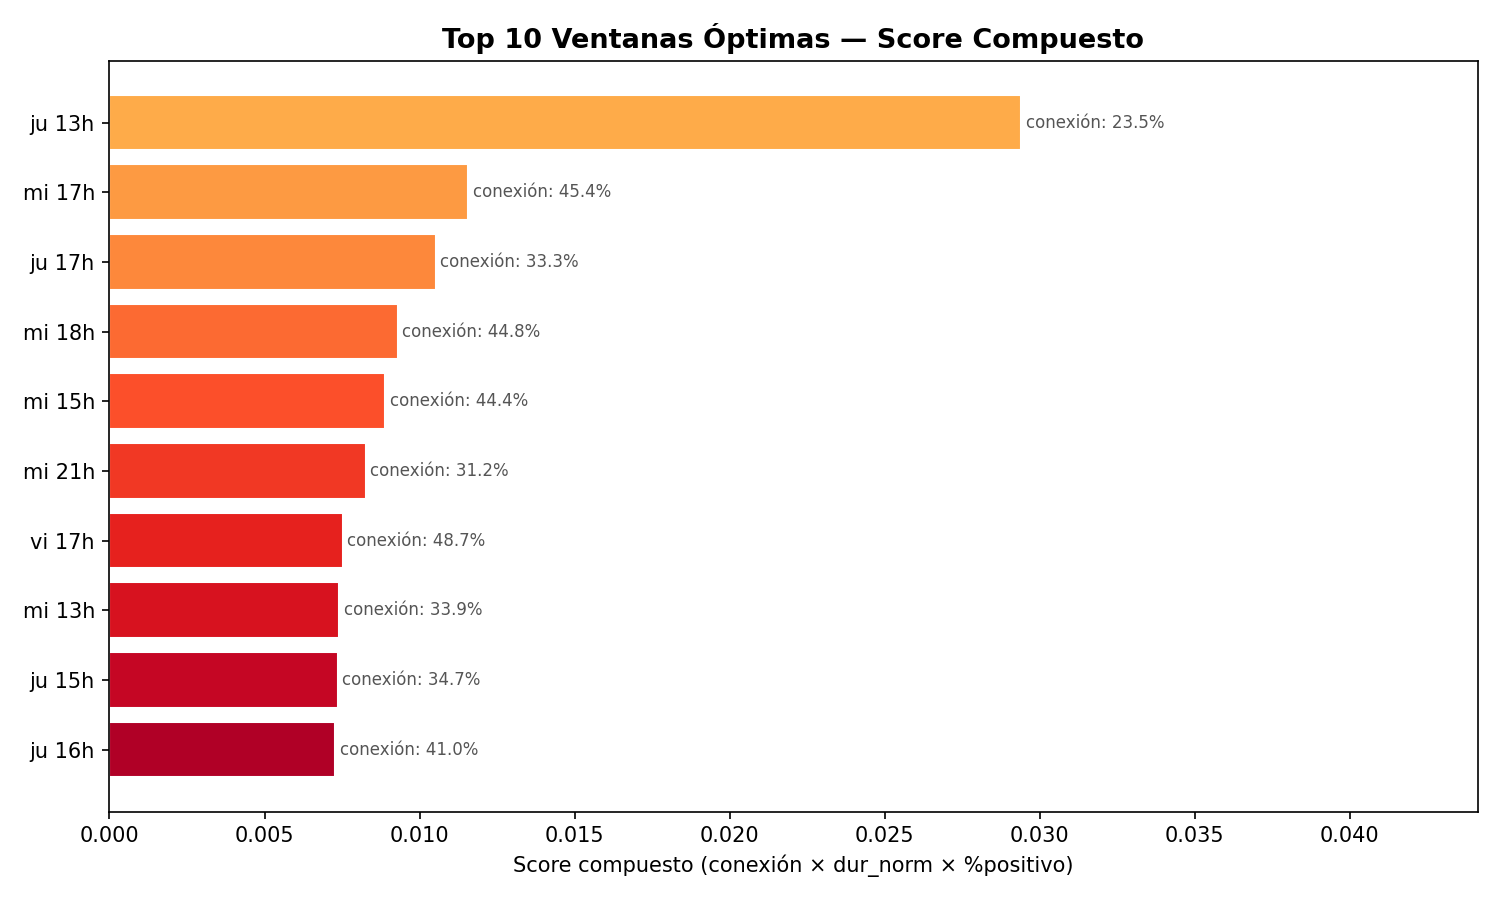

In [9]:
# Top 10 ventanas hora × día con mayor tasa de conexión (min 10 llamadas)
top_windows = (
    df.with_columns(pl.col("connected").cast(pl.Int32))
    .group_by(["day_of_week", "hour"])
    .agg([
        pl.len().alias("total"),
        pl.col("connected").sum().alias("conectadas"),
    ])
    .with_columns((pl.col("conectadas") / pl.col("total")).alias("tasa"))
    .filter(pl.col("total") >= 10)
    .sort("tasa", descending=True)
    .head(10)
)
print("Top 10 ventanas óptimas (día + hora):")
print(top_windows.select(["day_of_week", "hour", "total", "tasa"]))

# Fila 1: heatmap conexión | heatmap agent_hangup (llamadas completadas)
show_pair(FIGURES / "contactability_heatmap.png", FIGURES / "heatmap_agent_hangup_hour_dow.png")
# Fila 2: heatmap sentimiento positivo | score compuesto top 10 ventanas
show_pair(FIGURES / "heatmap_positive_sentiment_hour_dow.png", FIGURES / "optimal_windows_score.png")

Tomando como ventana los intervalos con un porcentaje superior al 20%
Lunes: 16pm
Martes: 19 a 20pm
Miercoles: 16 a 20pm
Jueves 15 a 17pm
Viernes: 16 a 18pm
Sabado: 16 a 17pm

Siendo los miercoles y viernes los días en los que la gente más contesta

---
# 1. Clusters de Contactos

> *De las llamadas conectadas, identifica clusters distintos de contactos.*

<details open>
<summary><h3>1.1 ¿Qué clusters emergen de los datos?</h3></summary>

**Algoritmo**: K-Means (scikit-learn) sobre las **8,855 llamadas conectadas** completas.

**Features (7)** seleccionadas por Cramér's V:

| Feature | Encoding | Justificación |
|---------|----------|---------------|
| `duration_sec` | StandardScaler | Mayor varianza; diferencia conversaciones largas/cortas |
| `hour` | StandardScaler | Contexto temporal del contacto |
| `disconnected_reason` | Ordinal: `user_hangup`=2, `agent_hangup`=1, resto=0 | Eje dominante según Cramér's V |
| `duration_outlier` | 0/1 | Marca llamadas con duración anómala |
| `inconsistency_flag` | 0/1 | Señal de calidad de la llamada |
| `pca_sentimiento` | Ordinal: positivo=2, neutral=1, negativo=0, **null→1** | Imputado sin excluir filas |
| `pca_razon_churn` | Binaria `tiene_motivo`: 0 si null/n/a/otro, 1 si tiene valor | ~99.8% null → binaria válida |

**Descartadas**: `day_of_week` (Cramér's V < 0.09 con todo → ruido puro).

**K elegido**: La selección automática por Silhouette da K=2 (sil=0.87), pero ese score alto refleja que `disconnected_reason` domina el espacio y produce una separación casi binaria. Al evaluar las métricas reales sobre el dataset completo, **K=4 es superior** en los 3 indicadores (Silhouette: 0.424, Davies-Bouldin: 0.939, Calinski-Harabasz: 3,762) y produce 4 segmentos accionables de negocio.
</details>

Distribución de Clusters (K-Means, K=4):

  C0 Sin contacto (inactivity/IVR)             2,139 (24.2%)  ████████████
  C1 Contacto breve (user_hangup <10s)         4,967 (56.1%)  ████████████████████████████
  C2 Conversación larga (user_hangup >15s)     1,720 (19.4%)  █████████
  C3 Caso documentado (churn + sentimiento)       29 ( 0.3%)  

  Total conectadas: 8,855



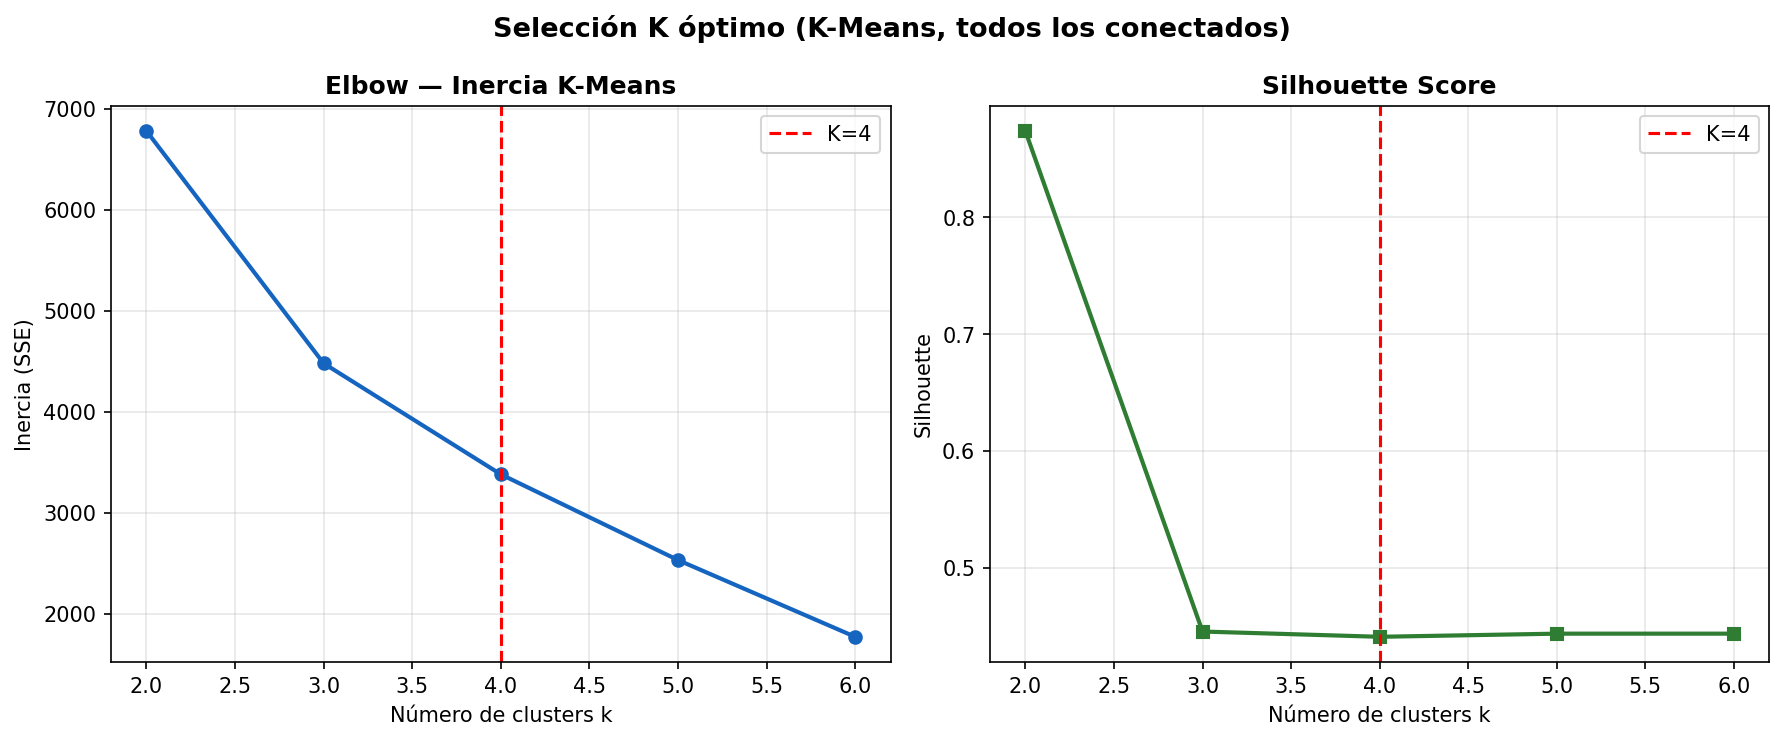
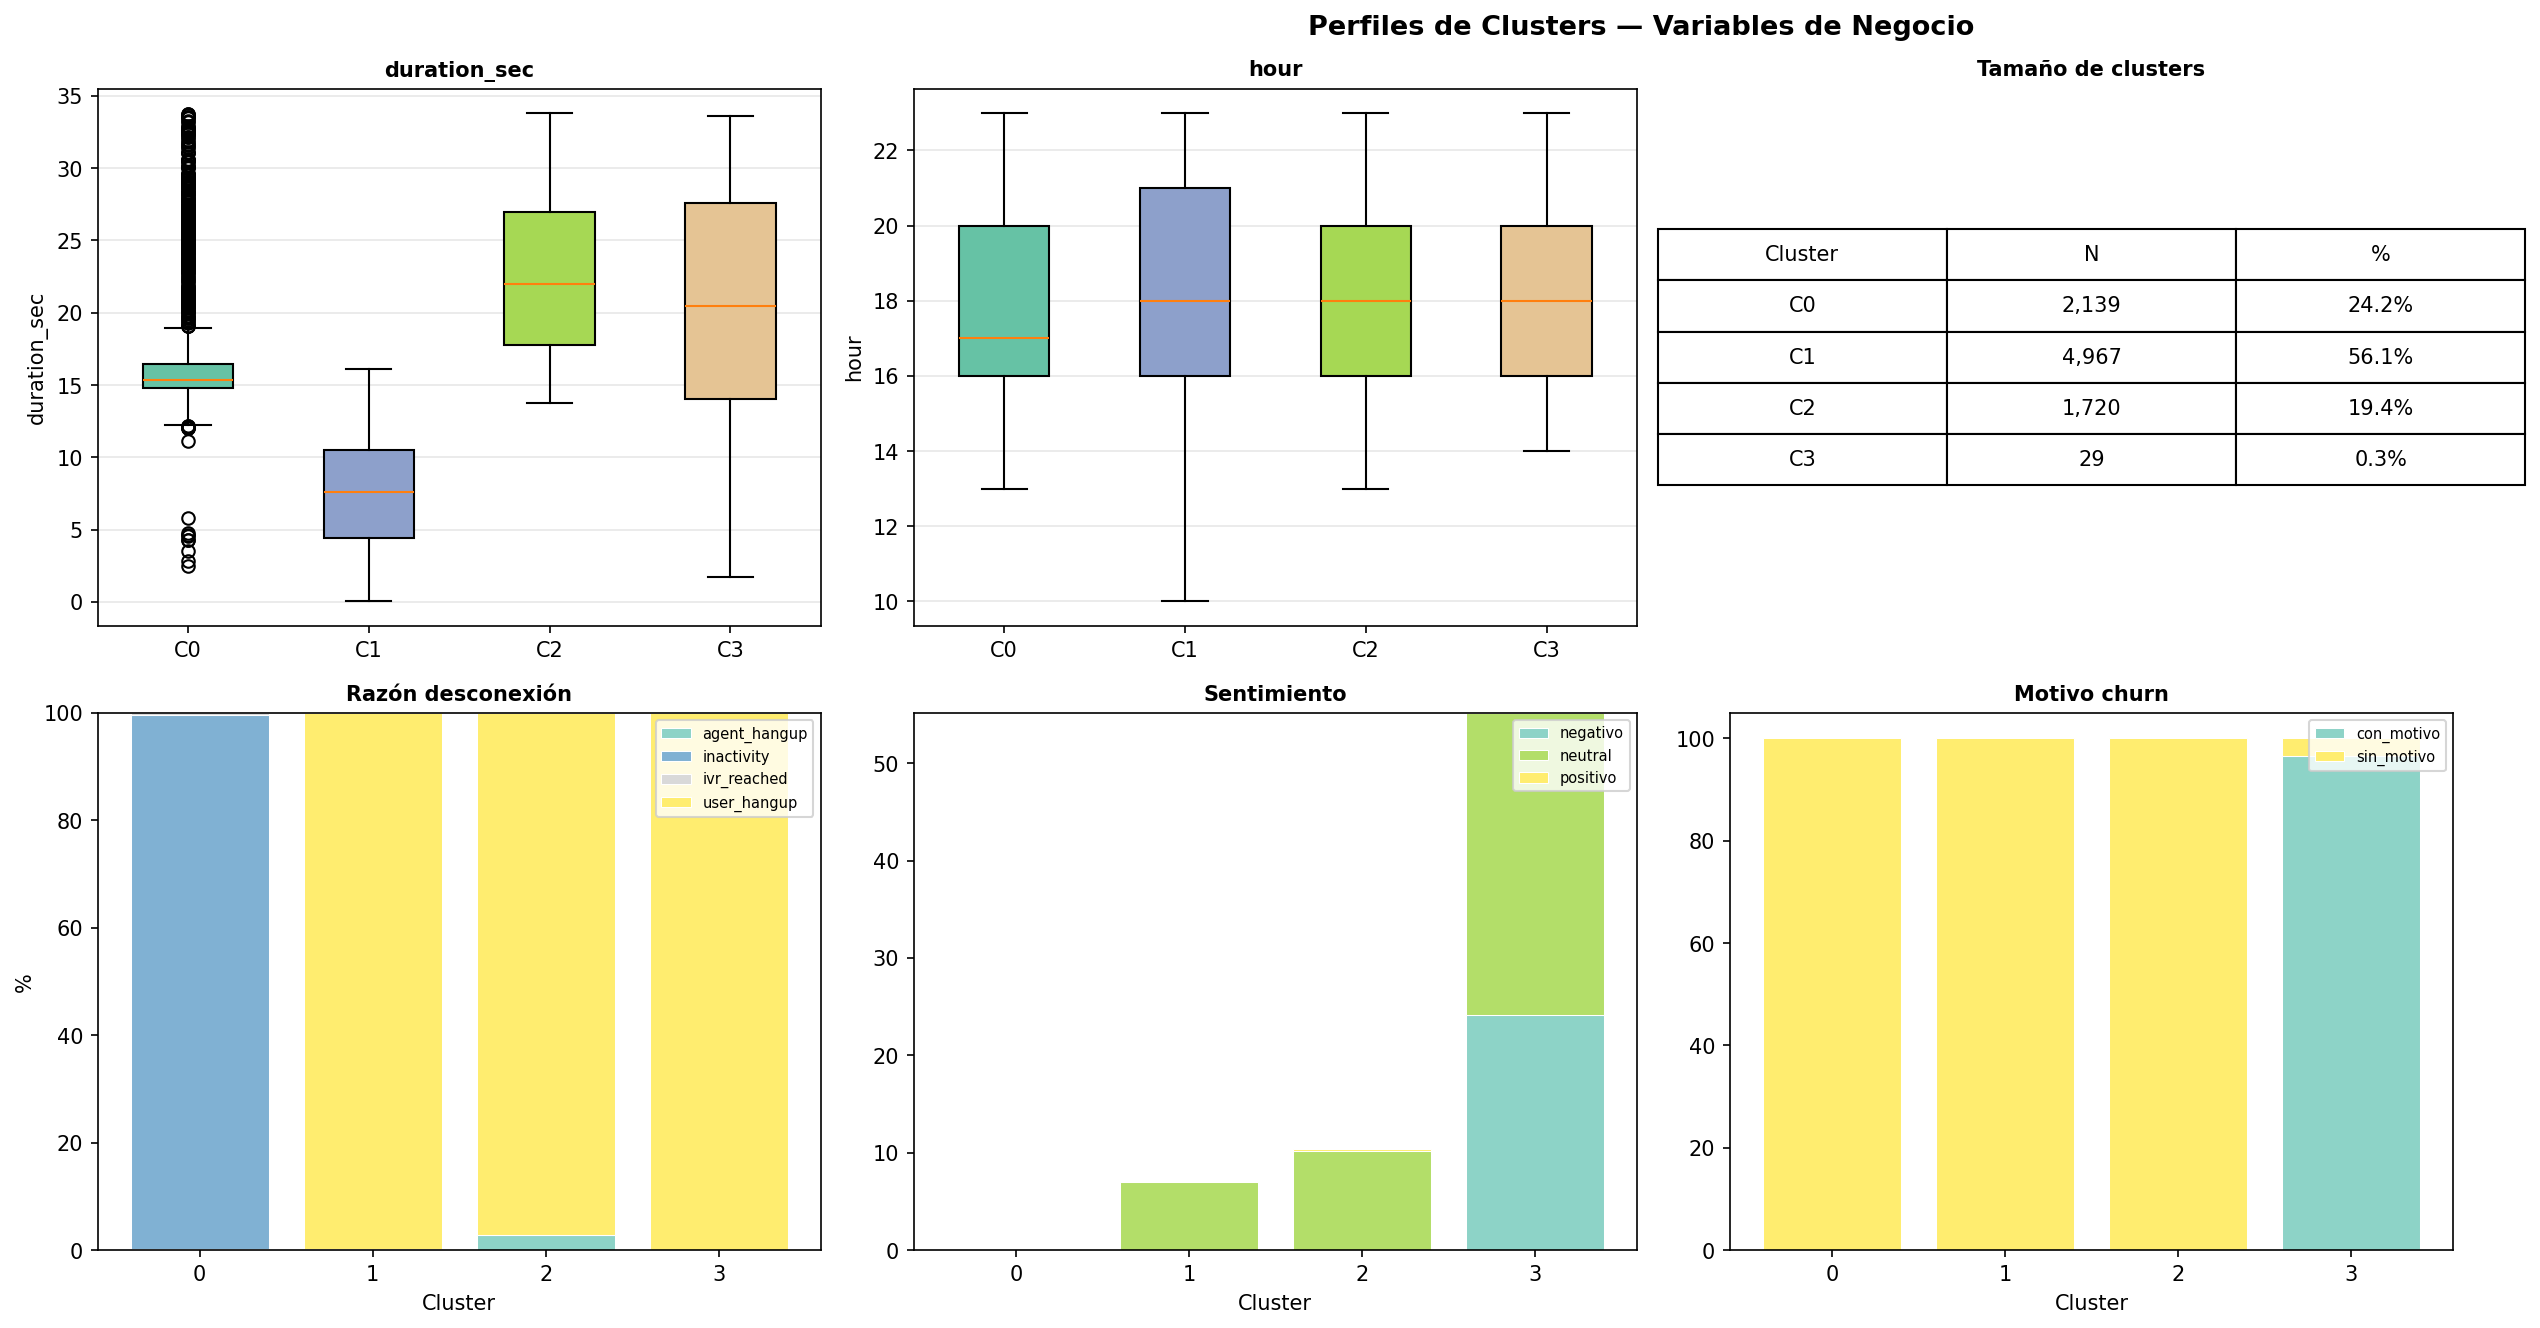

In [10]:
CLUSTER_LABELS = {
    0: "Sin contacto (inactivity/IVR)",
    1: "Contacto breve (user_hangup <10s)",
    2: "Conversación larga (user_hangup >15s)",
    3: "Caso documentado (churn + sentimiento)",
}

dist = (
    df_clusters.group_by("cluster_id")
    .agg(pl.len().alias("n"))
    .sort("cluster_id")
    .with_columns((pl.col("n") / pl.col("n").sum() * 100).round(1).alias("pct"))
)

print("Distribución de Clusters (K-Means, K=4):\n")
for row in dist.iter_rows(named=True):
    bar = "█" * int(row["pct"] / 2)
    print(f"  C{row['cluster_id']} {CLUSTER_LABELS[row['cluster_id']]:<40s}"
          f"  {row['n']:>5,} ({row['pct']:>4.1f}%)  {bar}")

print(f"\n  Total conectadas: {dist['n'].sum():,}")

# Selección K (elbow + silhouette) | Perfiles por cluster (stack=True: mucha info)
show_pair(FIGURES / "cluster_k_selection.png", FIGURES / "cluster_profiles.png", stack=True)

<details open>
<summary><h3>1.2 ¿Cuáles son las características y tendencias comunes dentro de cada cluster?</h3></summary>

Perfil de cada cluster: duración (mediana, IQR), hora de llamada, razón de desconexión, sentimiento y razón de churn.
</details>

In [11]:
# Perfil numérico por cluster
profile = (
    df_clusters.group_by("cluster_id")
    .agg([
        pl.col("duration_sec").median().round(1).alias("dur_median_s"),
        pl.col("duration_sec").quantile(0.25).round(1).alias("dur_p25_s"),
        pl.col("duration_sec").quantile(0.75).round(1).alias("dur_p75_s"),
        pl.col("hour").mean().round(1).alias("hour_mean"),
        pl.len().alias("n"),
    ])
    .sort("cluster_id")
    .with_columns(pl.col("cluster_id").replace_strict(CLUSTER_LABELS).alias("etiqueta"))
)
print("Perfil numérico por cluster:\n")
print(profile.select(["cluster_id", "etiqueta", "n", "dur_median_s", "dur_p25_s", "dur_p75_s", "hour_mean"]))

Perfil numérico por cluster:

shape: (4, 7)
┌────────────┬───────────────────────────┬──────┬──────────────┬───────────┬───────────┬───────────┐
│ cluster_id ┆ etiqueta                  ┆ n    ┆ dur_median_s ┆ dur_p25_s ┆ dur_p75_s ┆ hour_mean │
│ ---        ┆ ---                       ┆ ---  ┆ ---          ┆ ---       ┆ ---       ┆ ---       │
│ i64        ┆ str                       ┆ u32  ┆ f64          ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪═══════════════════════════╪══════╪══════════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ Sin contacto              ┆ 2139 ┆ 15.3         ┆ 14.8      ┆ 16.4      ┆ 17.9      │
│            ┆ (inactivity/IVR)          ┆      ┆              ┆           ┆           ┆           │
│ 1          ┆ Contacto breve            ┆ 4967 ┆ 7.6          ┆ 4.4       ┆ 10.5      ┆ 18.4      │
│            ┆ (user_hangup <1…          ┆      ┆              ┆           ┆           ┆           │
│ 2          ┆ Conversación larga        ┆ 1720

In [12]:
clusters = sorted(df_clusters["cluster_id"].unique().to_list())

# --- Razón de desconexión por cluster ---
print("Razón de desconexión por cluster:\n")
for cid in clusters:
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    reason = (
        sub.group_by("disconnected_reason")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / sub.height * 100).round(1).alias("pct"))
        .sort("n", descending=True)
    )
    print(f"  C{cid} — {CLUSTER_LABELS[cid]} ({sub.height:,})")
    for r in reason.iter_rows(named=True):
        print(f"    {r['disconnected_reason']:<25s} {r['n']:>5,}  ({r['pct']}%)")
    print()

# --- Sentimiento propio por cluster ---
print("Sentimiento (sentiment_own) por cluster:\n")
for cid in clusters:
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    sent = (
        sub.group_by("sentiment_own")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / sub.height * 100).round(1).alias("pct"))
        .sort("n", descending=True)
    )
    print(f"  C{cid} — {CLUSTER_LABELS[cid]}")
    for r in sent.iter_rows(named=True):
        print(f"    {str(r['sentiment_own']):<12s}  {r['n']:>5,}  ({r['pct']}%)")
    print()

# --- Razón de churn (solo registros con dato) ---
print("Razón de churn (top 5 por cluster, excluyendo null/n/a/otro):\n")
for cid in clusters:
    sub = df_clusters.filter(pl.col("cluster_id") == cid)
    razon = (
        sub.filter(pl.col("pca_razon_churn").is_not_null())
           .filter(~pl.col("pca_razon_churn").is_in(["n/a", "otro", ""]))
    )
    if razon.height == 0:
        print(f"  C{cid}: sin datos de churn\n")
        continue
    top = (
        razon.group_by("pca_razon_churn")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .head(5)
    )
    print(f"  C{cid} — {CLUSTER_LABELS[cid]} ({razon.height} con dato):")
    for r in top.iter_rows(named=True):
        print(f"    {r['pca_razon_churn']:<30s} {r['n']:>3,}")
    print()

Razón de desconexión por cluster:

  C0 — Sin contacto (inactivity/IVR) (2,139)
    inactivity                2,123  (99.3%)
    ivr_reached                  10  (0.5%)
    agent_hangup                  6  (0.3%)

  C1 — Contacto breve (user_hangup <10s) (4,967)
    user_hangup               4,958  (99.8%)
    agent_hangup                  9  (0.2%)

  C2 — Conversación larga (user_hangup >15s) (1,720)
    user_hangup               1,672  (97.2%)
    agent_hangup                 48  (2.8%)

  C3 — Caso documentado (churn + sentimiento) (29)
    user_hangup                  29  (100.0%)

Sentimiento (sentiment_own) por cluster:

  C0 — Sin contacto (inactivity/IVR)
    neutral       2,113  (98.8%)
    positivo         25  (1.2%)
    negativo          1  (0.0%)

  C1 — Contacto breve (user_hangup <10s)
    neutral       4,916  (99.0%)
    positivo         48  (1.0%)
    negativo          3  (0.1%)

  C2 — Conversación larga (user_hangup >15s)
    neutral       1,556  (90.5%)
    positivo

<details open>
<summary><h3>1.3 ¿Por qué están agrupados juntos? ¿Qué diferencia a cada cluster?</h3></summary>

**Eje principal — quién colgó (`disconnected_reason`)**: Separa C0 del resto. El 99% de C0 son `inactivity` (el sistema esperó ~15s sin respuesta y cortó solo). C1, C2 y C3 son todos `user_hangup` — el usuario participó activamente.

**Eje secundario — duración (`duration_sec`)**: Dentro de los `user_hangup`, separa C1 de C2/C3.
- C0 tiene IQR muy estrecho (14.8–16.4s) porque todos los timeouts de inactividad son uniformes — el sistema siempre espera el mismo tiempo antes de cortar.
- C1 (mediana 7.6s, IQR 4.4–10.5s) son conversaciones breves: el usuario colgó antes de los 10s.
- C2 (mediana 22s, IQR 17.7–26.9s) son conversaciones largas: el agente y el usuario interactuaron más tiempo.

**Eje terciario — razón de churn documentada**: Separa C3 del resto. C3 es el **único cluster donde `pca_razon_churn` tiene datos** (22 de 29 registros con `no_sabe_recargar`) y también el único con sentimiento negativo registrado en `pca_sentimiento`. Esto indica llamadas donde el agente logró capturar el motivo por el que el cliente está en riesgo de churn.
</details>

In [13]:
# Tabla resumen: feature clave por cluster que explica la agrupación
print("Resumen comparativo de ejes de separación:\n")
print(f"{'Cluster':<6} {'Etiqueta':<42} {'N':>5}  {'Disconnect dominante':<22} {'Dur. mediana':>12}  {'IQR (P25–P75)':<18}")
print("─" * 115)

for cid in clusters:
    sub  = df_clusters.filter(pl.col("cluster_id") == cid)
    disc = sub.group_by("disconnected_reason").agg(pl.len()).sort("len", descending=True).row(0)[0]
    med  = sub["duration_sec"].median()
    p25  = sub["duration_sec"].quantile(0.25)
    p75  = sub["duration_sec"].quantile(0.75)
    print(f"  C{cid}   {CLUSTER_LABELS[cid]:<42} {sub.height:>5,}  {disc:<22} {med:>10.1f}s  {p25:.1f}s – {p75:.1f}s")

# Hallazgo clave: IQR de C0 muy estrecho (timeout uniforme del sistema)
print()
c0_iqr = df_clusters.filter(pl.col("cluster_id") == 0)["duration_sec"].quantile(0.75) - \
         df_clusters.filter(pl.col("cluster_id") == 0)["duration_sec"].quantile(0.25)
print(f"  IQR de C0 (inactivity): {c0_iqr:.2f}s  → timeout del sistema fijo en ~15s")

# Hallazgo clave: C3 es el único con razón de churn documentada
c3_churn = df_clusters.filter(
    (pl.col("cluster_id") == 3) &
    pl.col("pca_razon_churn").is_not_null() &
    ~pl.col("pca_razon_churn").is_in(["n/a", "otro", ""])
).height
c3_total = df_clusters.filter(pl.col("cluster_id") == 3).height
print(f"  C3 con razón churn documentada: {c3_churn}/{c3_total} ({c3_churn/c3_total:.0%})")

# Métricas de calidad del clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import os
os.environ["OMP_NUM_THREADS"] = "1"

ENGAGEMENT_MAP = {"user_hangup": 2, "agent_hangup": 1}
SENTIMENT_MAP  = {"positivo": 2, "neutral": 1, "negativo": 0}
SIN_MOTIVO     = {None, "", "n/a", "otro", "sin_motivo"}
from sklearn.preprocessing import StandardScaler

dur_med    = float(df_clusters["duration_sec"].median() or 0.0)
duration   = df_clusters["duration_sec"].fill_null(dur_med).to_numpy(allow_copy=True).astype(float)
hour       = df_clusters["hour"].to_numpy(allow_copy=True).astype(float)
engagement = np.array([ENGAGEMENT_MAP.get(str(v) if v is not None else "", 0) for v in df_clusters["disconnected_reason"].to_list()], dtype=float)
outlier    = df_clusters["duration_outlier"].cast(pl.Float64).fill_null(0).to_numpy(allow_copy=True)
incons     = df_clusters["inconsistency_flag"].cast(pl.Float64).fill_null(0).to_numpy(allow_copy=True)
sentiment  = np.array([SENTIMENT_MAP.get(str(v) if v is not None else "", 1) for v in df_clusters["pca_sentimiento"].to_list()], dtype=float)
motivo     = np.array([0.0 if v in SIN_MOTIVO else 1.0 for v in df_clusters["pca_razon_churn"].to_list()], dtype=float)
X          = StandardScaler().fit_transform(np.column_stack([duration, hour, engagement, outlier, incons, sentiment, motivo]))
labels     = df_clusters["cluster_id"].to_numpy()

sil = silhouette_score(X, labels, sample_size=3000, random_state=42)
db  = davies_bouldin_score(X, labels)
ch  = calinski_harabasz_score(X, labels)
print(f"\n  Métricas de calidad (K=4):")
print(f"    Silhouette:          {sil:.4f}  (0=solapado, 1=perfecto)")
print(f"    Davies-Bouldin:      {db:.4f}  (menor es mejor)")
print(f"    Calinski-Harabasz: {ch:.1f}  (mayor es mejor)")

Resumen comparativo de ejes de separación:

Cluster Etiqueta                                       N  Disconnect dominante   Dur. mediana  IQR (P25–P75)     
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  C0   Sin contacto (inactivity/IVR)              2,139  inactivity                   15.3s  14.8s – 16.4s
  C1   Contacto breve (user_hangup <10s)          4,967  user_hangup                   7.6s  4.4s – 10.5s
  C2   Conversación larga (user_hangup >15s)      1,720  user_hangup                  22.0s  17.7s – 26.9s
  C3   Caso documentado (churn + sentimiento)        29  user_hangup                  20.5s  14.0s – 27.6s

  IQR de C0 (inactivity): 1.68s  → timeout del sistema fijo en ~15s
  C3 con razón churn documentada: 28/29 (97%)

  Métricas de calidad (K=4):
    Silhouette:          0.4244  (0=solapado, 1=perfecto)
    Davies-Bouldin:      0.9392  (menor es mejor)
    Calinski-Harabasz: 3762.9  (mayor es mejor

<details open>
<summary><h3>1.4 Razonamiento del enfoque de clustering y elección de K</h3></summary>

**¿Por qué K-Means y no K-Prototypes?**

K-Prototypes (la primera versión) es una implementación Python puro que en la práctica se cuelga en Windows por un bug de paralelismo (`n_jobs=-1` + `joblib/loky` sin `fork`). Más importante: todas las variables categóricas del dataset tienen cardinalidad ≤ 4 valores, lo que hace que un **encoding ordinal de dominio** (engagement: 0/1/2) sea semánticamente equivalente a usar distancias de Hamming, sin el costo computacional.

**¿Por qué descartar `day_of_week`?**

El análisis de Cramér's V mostró que `day_of_week` tiene asociación < 0.09 con todas las demás variables — es ruido puro para el clustering. Incluirlo solo añade dimensiones sin señal.

**¿Por qué K=4 y no K=2 (el que ganó automáticamente)?**

El Silhouette automático favoreció K=2 con score 0.87 — un valor sospechosamente alto. La causa: `disconnected_reason` con encoding 0/1/2 domina el espacio escalado y produce una separación casi binaria (user_hangup vs resto). Ese score no mide utilidad de negocio.

Al evaluar sobre el dataset completo:

| Métrica | K=2 | K=4 | Ganador |
|---------|-----|-----|---------|
| Silhouette (real) | 0.408 | **0.424** | K=4 |
| Davies-Bouldin (↓) | 1.004 | **0.939** | K=4 |
| Calinski-Harabasz (↑) | 2,495 | **3,763** | K=4 |

K=4 además produce segmentos **accionables**: separa las conversaciones breves de las largas dentro de user_hangup, y aísla los 29 casos con razón de churn documentada (C3) — el grupo más valioso informativamente.
</details>

---
# 2. Análisis de Sentimiento

> *Clasifica los contactos en sentimiento Negativo, Neutral y Positivo. Ve más allá de los campos existentes de Post Call Analysis — deriva tu propia clasificación de sentimiento y justifícala.*

<details open>
<summary><h3>2.1 Metodología propia de clasificación de sentimiento</h3></summary>

Se implementó un **clasificador léxico en español** (`scripts/sentiment_analysis.py`) que:

1. **Extrae solo el texto del usuario** del transcript (ignora líneas del Agent)
2. Evalúa **frases completas** con peso doble (ej. "no me interesa" = −2, "si me interesa" = +2)
3. Evalúa **palabras individuales** contra un léxico de ~70 términos positivos y ~70 negativos
4. Clasifica: score ≥ 1 → positivo | score ≤ −1 → negativo | resto → neutral
5. Llamadas sin texto de usuario → neutral (no hay señal para clasificar)

**Justificación**: Un enfoque léxico es transparente, auditable y no requiere modelos pesados. Es apropiado dado que el contexto es acotado (atención al cliente de telecomunicaciones en español) y los transcripts tienen ruido suficiente para que embeddings o LLMs introduzcan más incertidumbre que valor.

**Por qué "neutral" domina — contexto del clustering (sección 1)**:

| Cluster | % del total | Razón de neutralidad |
|---------|-------------|----------------------|
| C0 — Sin contacto | 24% | Usuario nunca habló (`inactivity`) → sin texto → neutral por defecto |
| C1 — Contacto breve | 56% | Llamada <10s → muy poco texto del usuario → score ≈ 0 |
| C2 — Conversación larga | 19% | Aquí se concentra la señal real de sentimiento |
| C3 — Caso documentado | 0.3% | Único cluster con `pca_sentimiento` negativo documentado por la IA original |

La neutralidad masiva no es un fallo del clasificador — es un reflejo estructural de que el 80% de las llamadas conectadas no generan suficiente texto del usuario para inferir sentimiento.
</details>

<details open>
<summary><h3>2.2 ¿Cuál es la distribución de sentimiento a través de las llamadas?</h3></summary>
</details>

In [14]:
# --- Distribución global ---
sent_dist = (
    df.group_by("sentiment_own")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df.height * 100).round(1).alias("pct"))
    .sort("n", descending=True)
)
print("Distribución de sentimiento propio (todas las llamadas):")
print(sent_dist)

# Solo conectadas
sent_conn = (
    df_connected.group_by("sentiment_own")
    .agg(pl.len().alias("n"))
    .with_columns((pl.col("n") / df_connected.height * 100).round(1).alias("pct"))
    .sort("n", descending=True)
)
print("\nDistribución (solo conectadas):")
print(sent_conn)

# Concordancia con pca_sentimiento (ground truth del sistema original)
overlap = df.filter(pl.col("pca_sentimiento").is_not_null())
if overlap.height > 0:
    match = overlap.filter(pl.col("sentiment_own") == pl.col("pca_sentimiento")).height
    print(f"\nConcordancia con pca_sentimiento (IA original): {match}/{overlap.height} = {match/overlap.height:.1%}")

    # Concordancia desglosada por cluster (conectadas con pca_sentimiento no null)
    overlap_conn = df_clusters.filter(pl.col("pca_sentimiento").is_not_null())
    print(f"\nConcordancia por cluster (n={overlap_conn.height} registros con pca_sentimiento):")
    for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
        sub = overlap_conn.filter(pl.col("cluster_id") == cid)
        if sub.height == 0:
            continue
        m = sub.filter(pl.col("sentiment_own") == pl.col("pca_sentimiento")).height
        print(f"  C{cid} [{CLUSTER_LABELS[cid]:<40s}]  {m}/{sub.height} = {m/sub.height:.1%}")

# --- Sentimiento propio por cluster ---
print("\nSentimiento propio × cluster (conectadas):\n")
for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
    sub   = df_clusters.filter(pl.col("cluster_id") == cid)
    total = sub.height
    sent  = (
        sub.group_by("sentiment_own")
        .agg(pl.len().alias("n"))
        .with_columns((pl.col("n") / total * 100).round(1).alias("pct"))
        .sort("n", descending=True)
    )
    partes = "  |  ".join(
        f"{r['sentiment_own']}: {r['n']:,} ({r['pct']}%)"
        for r in sent.iter_rows(named=True)
    )
    print(f"  C{cid}  {partes}")

Distribución de sentimiento propio (todas las llamadas):
shape: (3, 3)
┌───────────────┬───────┬──────┐
│ sentiment_own ┆ n     ┆ pct  │
│ ---           ┆ ---   ┆ ---  │
│ str           ┆ u32   ┆ f64  │
╞═══════════════╪═══════╪══════╡
│ neutral       ┆ 25260 ┆ 99.0 │
│ positivo      ┆ 242   ┆ 0.9  │
│ negativo      ┆ 14    ┆ 0.1  │
└───────────────┴───────┴──────┘

Distribución (solo conectadas):
shape: (3, 3)
┌───────────────┬──────┬──────┐
│ sentiment_own ┆ n    ┆ pct  │
│ ---           ┆ ---  ┆ ---  │
│ str           ┆ u32  ┆ f64  │
╞═══════════════╪══════╪══════╡
│ neutral       ┆ 8607 ┆ 97.2 │
│ positivo      ┆ 236  ┆ 2.7  │
│ negativo      ┆ 12   ┆ 0.1  │
└───────────────┴──────┴──────┘

Concordancia con pca_sentimiento (IA original): 1776/1800 = 98.7%

Concordancia por cluster (n=539 registros con pca_sentimiento):
  C1 [Contacto breve (user_hangup <10s)       ]  341/345 = 98.8%
  C2 [Conversación larga (user_hangup >15s)   ]  170/178 = 95.5%
  C3 [Caso documentado (churn + sen

<details open>
<summary><h3>2.3 ¿Qué impulsa cada categoría? Ejemplos concretos de transcripciones</h3></summary>
</details>

In [15]:
# Ejemplos representativos de cada sentimiento (solo texto del usuario, llamadas conectadas)
import re

def extract_user_text(transcript):
    if not transcript:
        return ""
    return " | ".join(
        line.strip()[5:].strip()
        for line in transcript.split("\n")
        if line.strip().startswith("User:")
    )

for sentiment in ["positivo", "negativo", "neutral"]:
    sample = (
        df_connected
        .filter(
            (pl.col("sentiment_own") == sentiment)
            & pl.col("transcript_text").is_not_null()
            & (pl.col("transcript_length") > 100)
        )
        .sample(n=min(3, df_connected.filter(
            (pl.col("sentiment_own") == sentiment)
            & pl.col("transcript_text").is_not_null()
            & (pl.col("transcript_length") > 100)
        ).height), seed=42)
    )
    print(f"\n{'='*70}")
    print(f"  SENTIMIENTO: {sentiment.upper()} ({sample.height} ejemplos)")
    print(f"{'='*70}")
    for i, row in enumerate(sample.iter_rows(named=True)):
        user_text = extract_user_text(row["transcript_text"])
        if len(user_text) > 300:
            user_text = user_text[:300] + "..."
        print(f"\n  [{i+1}] Duración: {row['duration_sec']:.0f}s | Razón: {row['disconnected_reason']}")
        print(f"      Usuario dijo: \"{user_text}\"")


  SENTIMIENTO: POSITIVO (3 ejemplos)

  [1] Duración: 30s | Razón: user_hangup
      Usuario dijo: "Aló. | Pero no es Jaimito, ¿aló? | Sí, señorita, pero no estoy interesada ahora. | Muchas gracias."

  [2] Duración: 27s | Razón: inactivity
      Usuario dijo: "¿Bueno?"

  [3] Duración: 20s | Razón: user_hangup
      Usuario dijo: "Hello. | Bueno, este, excelente. | Ya."

  SENTIMIENTO: NEGATIVO (3 ejemplos)

  [1] Duración: 8s | Razón: user_hangup
      Usuario dijo: "Aló. No, mi amor, yo no quiero más plan,"

  [2] Duración: 23s | Razón: agent_hangup
      Usuario dijo: "Estás equivocada. | No, amiga, no quiero hablar contigo, no sé quién eres."

  [3] Duración: 14s | Razón: user_hangup
      Usuario dijo: "Esta foto | es cuestión en robo, | voy a a contestar."

  SENTIMIENTO: NEUTRAL (3 ejemplos)

  [1] Duración: 19s | Razón: user_hangup
      Usuario dijo: ""

  [2] Duración: 17s | Razón: user_hangup
      Usuario dijo: "Aló. | (inaudible speech)"

  [3] Duración: 10s | Razón: use

<details open>
<summary><h3>2.4 ¿Hay patrones por tipo de campaña, hora del día, o duración?</h3></summary>
</details>

In [16]:
# --- Sentimiento por tipo de campaña (conectadas) ---
print("Sentimiento por tipo de campaña (solo conectadas):\n")
pivot_camp = (
    df_connected.group_by(["campaign_type", "sentiment_own"])
    .agg(pl.len().alias("n"))
    .sort(["campaign_type", "sentiment_own"])
)
pivot = pivot_camp.pivot(on="sentiment_own", index="campaign_type", values="n").fill_null(0)
# Agregar % negativo para ordenar por conflictividad
totales = df_connected.group_by("campaign_type").agg(pl.len().alias("total"))
pivot = pivot.join(totales, on="campaign_type")
if "negativo" in pivot.columns:
    pivot = pivot.with_columns(
        (pl.col("negativo") / pl.col("total") * 100).round(1).alias("pct_neg")
    ).sort("pct_neg", descending=True)
print(pivot)

# --- Sentimiento por duración (conectadas) ---
print("\nDuración media por sentimiento (solo conectadas):\n")
dur_by_sent = (
    df_connected.group_by("sentiment_own")
    .agg([
        pl.col("duration_sec").mean().round(1).alias("dur_mean_s"),
        pl.col("duration_sec").median().round(1).alias("dur_median_s"),
        pl.len().alias("n"),
    ])
    .sort("n", descending=True)
)
print(dur_by_sent)

# --- Sentimiento por hora (top 5 horas con más negativos) ---
print("\nDistribución de sentimiento negativo por hora (top 5):\n")
neg_by_hour = (
    df_connected.filter(pl.col("sentiment_own") == "negativo")
    .group_by("hour")
    .agg(pl.len().alias("n_negativo"))
    .sort("n_negativo", descending=True)
    .head(5)
)
print(neg_by_hour)

# --- NUEVO: sentimiento × cluster — dónde se concentra la señal real ---
print("\n--- Sentimiento por cluster: dónde vive la señal real ---\n")
sent_cluster = (
    df_clusters.group_by(["cluster_id", "sentiment_own"])
    .agg(pl.len().alias("n"))
    .sort(["cluster_id", "n"], descending=[False, True])
)
total_positivo = df_clusters.filter(pl.col("sentiment_own") == "positivo").height
total_negativo = df_clusters.filter(pl.col("sentiment_own") == "negativo").height

for cid in sorted(df_clusters["cluster_id"].unique().to_list()):
    sub   = df_clusters.filter(pl.col("cluster_id") == cid)
    n_pos = sub.filter(pl.col("sentiment_own") == "positivo").height
    n_neg = sub.filter(pl.col("sentiment_own") == "negativo").height
    n_neu = sub.filter(pl.col("sentiment_own") == "neutral").height
    pct_pos_global = n_pos / total_positivo * 100 if total_positivo > 0 else 0
    pct_neg_global = n_neg / total_negativo * 100 if total_negativo > 0 else 0
    print(f"  C{cid} {CLUSTER_LABELS[cid]}")
    print(f"    positivo: {n_pos:>4}  ({n_pos/sub.height:.1%} del cluster | {pct_pos_global:.1f}% del total positivos)")
    print(f"    negativo: {n_neg:>4}  ({n_neg/sub.height:.1%} del cluster | {pct_neg_global:.1f}% del total negativos)")
    print(f"    neutral:  {n_neu:>4}  ({n_neu/sub.height:.1%} del cluster)")
    print()

Sentimiento por tipo de campaña (solo conectadas):

shape: (8, 6)
┌──────────────────┬─────────┬──────────┬──────────┬───────┬─────────┐
│ campaign_type    ┆ neutral ┆ positivo ┆ negativo ┆ total ┆ pct_neg │
│ ---              ┆ ---     ┆ ---      ┆ ---      ┆ ---   ┆ ---     │
│ str              ┆ u32     ┆ u32      ┆ u32      ┆ u32   ┆ f64     │
╞══════════════════╪═════════╪══════════╪══════════╪═══════╪═════════╡
│ servicio_cliente ┆ 340     ┆ 10       ┆ 1        ┆ 351   ┆ 0.3     │
│ upsell           ┆ 1992    ┆ 57       ┆ 4        ┆ 2053  ┆ 0.2     │
│ churn_prevention ┆ 4644    ┆ 115      ┆ 7        ┆ 4766  ┆ 0.1     │
│ aviso            ┆ 695     ┆ 18       ┆ 0        ┆ 713   ┆ 0.0     │
│ promo            ┆ 45      ┆ 1        ┆ 0        ┆ 46    ┆ 0.0     │
│ prueba           ┆ 1       ┆ 0        ┆ 0        ┆ 1     ┆ 0.0     │
│ cobranza         ┆ 261     ┆ 10       ┆ 0        ┆ 271   ┆ 0.0     │
│ otro             ┆ 629     ┆ 25       ┆ 0        ┆ 654   ┆ 0.0     │
└──────────

---
# 3. Desempeño del Agente Yarvis

> *Identifica casos donde el agente de IA se desempeñó pobremente durante llamadas.*

<details open>
<summary><h3>3.1 ¿Qué tipos de fallas ocurren y qué tan frecuentes son?</h3></summary>

Se detectaron 4 tipos de falla en `scripts/agent_performance.py`:

| Flag | Definición |
|------|-----------|
| `fail_repetitive` | El agente repite la misma frase ≥ 2 veces (normalizada, > 20 chars) |
| `fail_inactivity` | La llamada terminó por `inactivity` (timeout sin respuesta) |
| `fail_objection` | Existe `pca_razon_churn` + sentimiento negativo + sin recuperación posible |
| `fail_misunderstanding` | Llamada < 30s + `user_hangup` + sentimiento negativo |
</details>

Fallas detectadas sobre 8,855 llamadas conectadas:

  Respuestas repetitivas             :     7 (0.1%)
  Inactividad (timeout)              : 2,123 (24.0%)
  Sin manejo de objeción             :     5 (0.1%)
  Malentendido / llamada corta       :     7 (0.1%)
  Agente cuelga (agent_hangup)       :    63 (0.7%)

  Llamadas con ≥1 falla:              2,198 (24.8%)


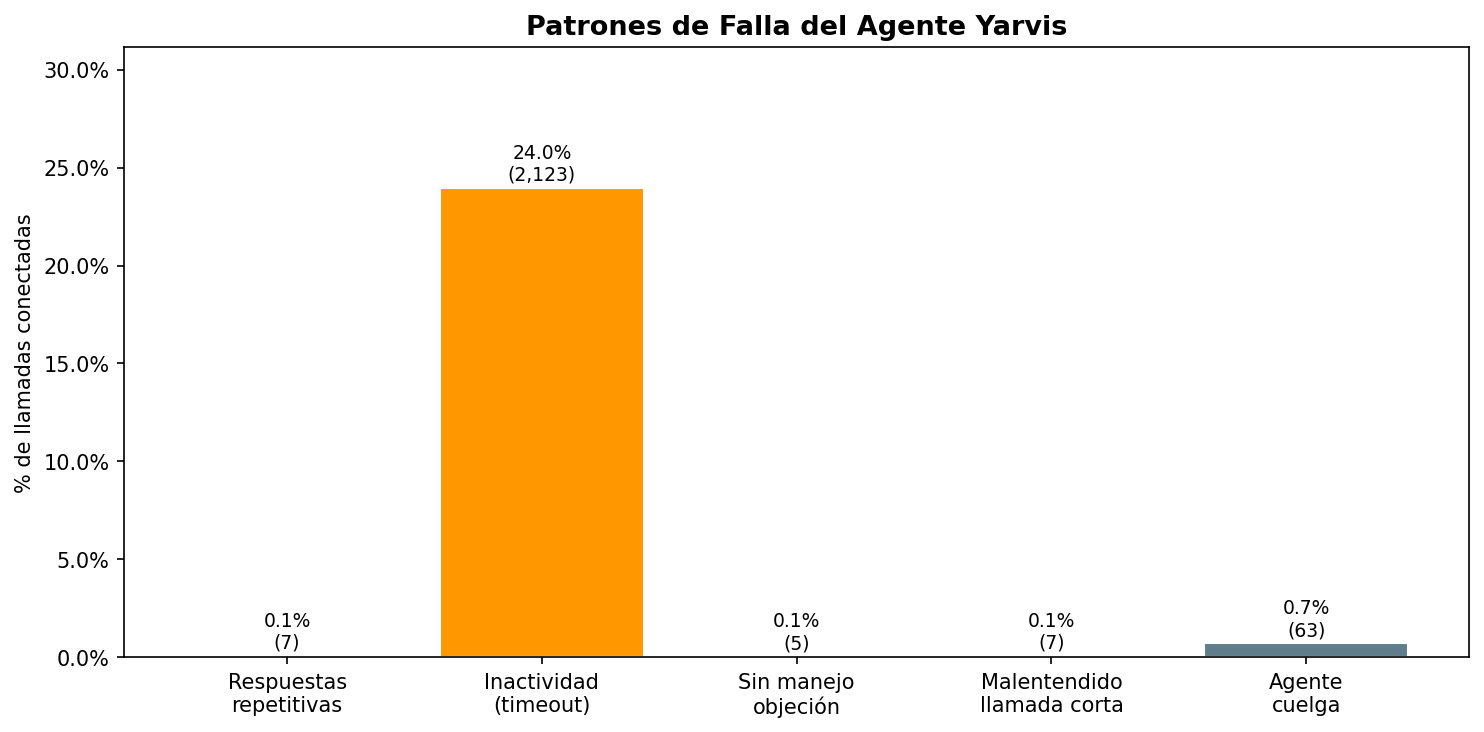

In [17]:
# Frecuencia de cada tipo de falla
fail_cols = ["fail_repetitive", "fail_inactivity", "fail_objection", "fail_misunderstanding", "fail_agent_hangup"]
fail_labels = [
    "Respuestas repetitivas",
    "Inactividad (timeout)",
    "Sin manejo de objeción",
    "Malentendido / llamada corta",
    "Agente cuelga (agent_hangup)",
]
n_conn = df_connected.height

print(f"Fallas detectadas sobre {n_conn:,} llamadas conectadas:\n")
for col, label in zip(fail_cols, fail_labels):
    count = df_connected[col].sum()
    pct = count / n_conn * 100
    print(f"  {label:35s}: {count:5,} ({pct:.1f}%)")

# Llamadas con al menos 1 falla
any_fail = df_connected.filter(
    pl.any_horizontal(*[pl.col(c) for c in fail_cols])
)
print(f"\n  Llamadas con ≥1 falla:              {any_fail.height:5,} ({any_fail.height/n_conn*100:.1f}%)")

display(IPImage(str(FIGURES / "agent_failures.png")))

<details open>
<summary><h3>3.2 ¿Qué patrones llevan a un mal desempeño? Ejemplos</h3></summary>

La **inactividad (timeout)** domina con el 24.0% de las llamadas conectadas (2,123 de 8,855). El resto de fallas son marginales (< 1% cada una). Los patrones identificados:

- **Inactividad (timeout)** — el agente no mantiene el engagement y la llamada se corta por silencio. Es especialmente severo en **servicio_cliente** (87.7%) y **upsell** (39.5%), donde el usuario probablemente no comprende la propuesta o no responde.
- **Agente cuelga (agent_hangup)** — 63 casos (0.7%). Concentrado en **Cluster 2** (llamadas largas, 2.8%), lo que sugiere que el agente abandona conversaciones prolongadas sin resolución.
- **Respuestas repetitivas** — solo 7 casos globales, pero **cobranza** tiene la tasa más alta (1.5%). El agente entra en loop cuando el usuario no coopera con el flujo de cobro.
- **Sin manejo de objeción** — 5 casos, todos en **churn_prevention**. El usuario expresa razón de churn con sentimiento negativo y el agente no logra retenerlo.
- **Malentendido / llamada corta** — 7 casos. El usuario cuelga en < 30s con sentimiento negativo — la apertura de la llamada no comunica contexto suficiente.

Los ejemplos concretos de cada caso se muestran en la celda siguiente.
</details>

In [18]:
# Ejemplos de cada tipo de falla (transcripts resumidos)
for col, label in zip(fail_cols, fail_labels):
    examples = (
        df_connected
        .filter(pl.col(col) == True)
        .filter(pl.col("transcript_text").is_not_null())
        .filter(pl.col("transcript_length") > 50)
        .sample(n=min(2, df_connected.filter(pl.col(col) == True).height), seed=42)
    )
    print(f"\n{'='*70}")
    print(f"  FALLA: {label.upper()}")
    print(f"{'='*70}")
    if examples.height == 0:
        print("  (sin ejemplos con transcript disponible)")
        continue
    for i, row in enumerate(examples.iter_rows(named=True)):
        txt = row["transcript_text"] or ""
        if len(txt) > 400:
            txt = txt[:400] + "..."
        print(f"\n  [{i+1}] Duración: {row['duration_sec']:.0f}s | Razón: {row['disconnected_reason']} | Sent: {row['sentiment_own']}")
        print(f"      Transcript: \"{txt}\"")


  FALLA: RESPUESTAS REPETITIVAS

  [1] Duración: 25s | Razón: user_hangup | Sent: neutral
      Transcript: "Agent: Hola, te llamamos de Fibrazo, la empresa de Internet. ¿Hablo con {{first_name}}?
User: Aló.
Agent: Hola, te llamamos de Fibrazo, la empresa de Internet. ¿Hablo con {{first_name}}?"

  [2] Duración: 17s | Razón: inactivity | Sent: neutral
      Transcript: "Agent: Hola, ¿hablo con Jesus David?
User: (inaudible speech)
Agent: Hola, ¿hablo con Jesus David?"

  FALLA: INACTIVIDAD (TIMEOUT)

  [1] Duración: 14s | Razón: inactivity | Sent: neutral
      Transcript: "Agent: Hola, ¿cómo vas? Te habla Aleja de Fibrazo la empresa de internet."

  [2] Duración: 16s | Razón: inactivity | Sent: neutral
      Transcript: "Agent: Hola buen día, te llama 
User: Aló.
Agent: Susana de Fibrazo

(espera un momento mientras el cliente responde)"

  FALLA: SIN MANEJO DE OBJECIÓN

  [1] Duración: 30s | Razón: user_hangup | Sent: negativo
      Transcript: "Agent: Hola , ¿cómo vas? Te 
User: Al

<details open>
<summary><h3>3.3 Fallas cruzadas con campaña y cluster</h3></summary>

**Por campaña:**
- **servicio_cliente** es la campaña más problemática: 87.7% de inactividad — el agente pierde al usuario casi siempre.
- **upsell** tiene 39.5% de inactividad y 0.5% de agent_hangup — el usuario no responde a ofertas o el agente no encuentra cómo enganchar.
- **aviso** y **otro** rondan 27-31% de inactividad.
- **churn_prevention** tiene la mayor diversidad de fallas (repetitivas, objeción, malentendido, agent_hangup) aunque las tasas son bajas individualmente. Es la campaña más compleja conversacionalmente.
- **cobranza** destaca en repetitivas (1.5%) y agent_hangup (1.5%) — el agente se estanca en el flujo de cobro.

**Por cluster:**
- **Cluster 0** (2,139 llamadas) = "cluster de inactividad": 99.3% tiene timeout. Son llamadas que nunca se convirtieron en conversación real.
- **Cluster 1** (4,967) es el más limpio — fallas mínimas (< 0.2% en todo).
- **Cluster 2** (1,720) concentra el **agent_hangup** (2.8%) — son conversaciones largas donde el agente termina colgando, posiblemente por no encontrar resolución.
- **Cluster 3** (29) es muy pequeño pero tiene tasas altas por su tamaño (3.4% objeción y malentendido).

El heatmap de `agent_hangup` por hora×día se muestra abajo para identificar patrones temporales.
</details>

Tasa de fallas por tipo de campaña:

shape: (8, 6)
┌──────────────────┬──────┬────────────────┬────────────────┬───────────────┬──────────────────┐
│ campaign_type    ┆ n    ┆ pct_inactivity ┆ pct_repetitive ┆ pct_objection ┆ pct_agent_hangup │
│ ---              ┆ ---  ┆ ---            ┆ ---            ┆ ---           ┆ ---              │
│ str              ┆ u32  ┆ f64            ┆ f64            ┆ f64           ┆ f64              │
╞══════════════════╪══════╪════════════════╪════════════════╪═══════════════╪══════════════════╡
│ servicio_cliente ┆ 351  ┆ 87.7           ┆ 0.0            ┆ 0.0           ┆ 0.0              │
│ upsell           ┆ 2053 ┆ 39.5           ┆ 0.1            ┆ 0.0           ┆ 0.5              │
│ aviso            ┆ 713  ┆ 30.7           ┆ 0.0            ┆ 0.0           ┆ 1.0              │
│ otro             ┆ 654  ┆ 26.5           ┆ 0.0            ┆ 0.0           ┆ 1.1              │
│ churn_prevention ┆ 4766 ┆ 12.8           ┆ 0.0            ┆ 0.1           

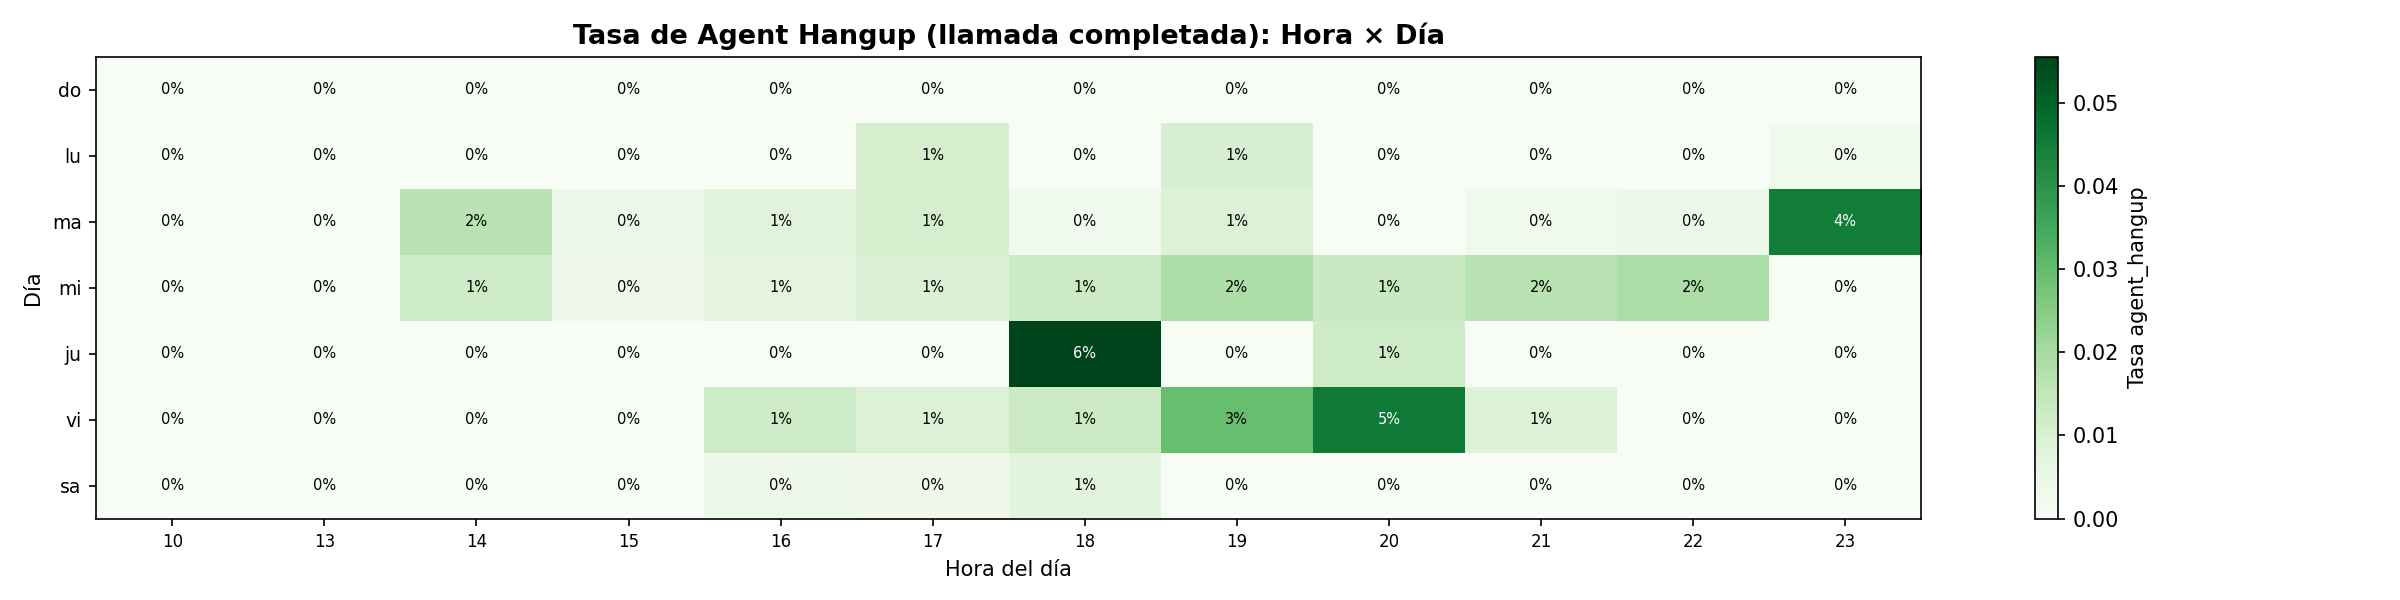

In [19]:
# Tasa de fallas por tipo de campaña
print("Tasa de fallas por tipo de campaña:\n")
inact_by_camp = (
    df_connected.group_by("campaign_type")
    .agg([
        pl.len().alias("n"),
        pl.col("fail_inactivity").sum().alias("n_inactivity"),
        pl.col("fail_repetitive").sum().alias("n_repetitive"),
        pl.col("fail_objection").sum().alias("n_objection"),
        pl.col("fail_agent_hangup").sum().alias("n_agent_hangup"),
    ])
    .with_columns([
        (pl.col("n_inactivity")   / pl.col("n") * 100).round(1).alias("pct_inactivity"),
        (pl.col("n_repetitive")   / pl.col("n") * 100).round(1).alias("pct_repetitive"),
        (pl.col("n_objection")    / pl.col("n") * 100).round(1).alias("pct_objection"),
        (pl.col("n_agent_hangup") / pl.col("n") * 100).round(1).alias("pct_agent_hangup"),
    ])
    .sort("pct_inactivity", descending=True)
)
print(inact_by_camp.select(["campaign_type", "n", "pct_inactivity", "pct_repetitive", "pct_objection", "pct_agent_hangup"]))

# Fallas por cluster
print("\nFallas por cluster:\n")
for cid in sorted(df_connected.filter(pl.col("cluster_id") >= 0)["cluster_id"].unique().to_list()):
    sub = df_connected.filter(pl.col("cluster_id") == cid)
    n = sub.height
    label = CLUSTER_LABELS.get(cid, f"Cluster {cid}")
    print(f"Cluster {cid} — {label} ({n:,} llamadas):")
    for col, lbl in zip(fail_cols, fail_labels):
        count = sub[col].sum()
        print(f"  {lbl:35s}: {count:4,} ({count/n*100:.1f}%)")
    print()

# Heatmap agent_hangup por hora × día (señal de abandono prematuro del agente)
display(IPImage(str(FIGURES / "heatmap_agent_hangup_hour_dow.png")))

<details open>
<summary><h3>3.4 Recomendaciones concretas de mejora</h3></summary>

| Problema | Frecuencia | Campañas críticas | Recomendación |
|----------|-----------|-------------------|---------------|
| **Inactividad (timeout)** | 24.0% (2,123) | servicio_cliente (87.7%), upsell (39.5%) | Reducir timeout; agregar fallback "¿Sigues ahí?" antes de cortar; mejorar apertura para enganchar rápido |
| **Agente cuelga (agent_hangup)** | 0.7% (63) | cobranza (1.5%), otro (1.1%) | Agregar escalamiento a humano cuando la conversación supera un umbral sin resolución, en vez de colgar |
| **Respuestas repetitivas** | 0.1% (7) | cobranza (1.5%) | Detectar loop de frases repetidas en runtime y cambiar estrategia/escalar |
| **Sin manejo de objeción** | 0.1% (5) | churn_prevention (0.1%) | Entrenar al agente con objeciones frecuentes de churn (precio, competencia, servicio) |
| **Malentendido / llamada corta** | 0.1% (7) | churn_prevention (0.1%) | Mejorar apertura de llamada con contexto más claro del motivo de contacto |

**Prioridad**: la inactividad concentra el **96.6%** de todas las fallas detectadas. Resolver este problema tendría el mayor impacto en el desempeño global del agente.
</details>